In [1]:
# =========================
# CELL 1 v4 -stage 3 add gain los 
# =========================

import warnings
warnings.filterwarnings("ignore")

from dataclasses import asdict, dataclass
from itertools import product
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False


RANDOM_STATE = 42
DATA_PATH = "/kaggle/input/datasets/umerrtx/machine-failure-prediction-using-sensor-data/data.csv"
TARGET = "fail"

TEST_SIZE = 0.15
VALID_SIZE_OF_REMAINDER = 0.17647058823529413

INSPECT_COST = 10.0
MISSED_FAILURE_COST = 500.0
CAPACITY_STEP = 5

# Stage 3 row-level business values.
# 10 and 500 are the Scania APS benchmark proxy costs:
# 10 = unnecessary check, 500 = missed faulty machine.
# Recovery rate is a modeling assumption: missed loss means avoidable loss.
ROW_CHECK_COST = INSPECT_COST
BASE_ROW_MISSED_LOSS = MISSED_FAILURE_COST
ROW_VALUE_RECOVERY_RATE = 1.0
ROW_VALUE_SEGMENTS = 3
ROW_VALUE_TOP_FEATURES = 5

QUEUE_EXPORT_PATH = "locked_test_queue.csv"
SUMMARY_EXPORT_PATH = "locked_test_summary.csv"
CANDIDATE_EXPORT_PATH = "candidate_results.csv"
CONFUSION_EXPORT_PATH = "locked_test_confusion_matrix.csv"
FEATURE_IMPORTANCE_EXPORT_PATH = "winning_model_feature_importance.csv"
THRESHOLD_STABILITY_EXPORT_PATH = "threshold_stability_check.csv"
BASELINE_EXPORT_PATH = "baseline_comparison.csv"
COST_SENSITIVITY_EXPORT_PATH = "cost_recovery_sensitivity.csv"
LEAKAGE_CHECK_EXPORT_PATH = "leakage_check.csv"

STAGE1_EXPORT_PATH = "stage1_ml_quality_results.csv"
STAGE2_EXPORT_PATH = "stage2_threshold_capture_results.csv"
STAGE3_EXPORT_PATH = "stage3_final_policy_results.csv"

MODEL_NAMES = ["logistic_regression", "extra_trees", "gradient_boosting", "xgboost"]
WEIGHT_STYLES = ["none", "balanced_x0.75", "balanced", "balanced_x1.25", "balanced_x1.5"]
WEIGHT_MULTIPLIERS = {
    "balanced_x0.75": 0.75,
    "balanced": 1.0,
    "balanced_x1.25": 1.25,
    "balanced_x1.5": 1.5,
}

THRESHOLD_MULTIPLIERS = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15]
INSPECT_COST_MULTIPLIERS = [0.50, 1.00, 1.50]
MISSED_COST_MULTIPLIERS = [0.50, 1.00, 1.50]
RECOVERY_RATES = [0.60, 0.80, 1.00]

RANDOM_BASELINE_ROUNDS = 300
PERMUTATION_SAMPLE_N = 600


@dataclass(frozen=True)
class CandidateSpec:
    model_name: str
    weight_style: str


@dataclass
class ThresholdResult:
    threshold: float
    selected_count: int
    true_positives: int
    false_positives: int
    false_negatives: int
    precision: float
    recall: float
    f1_score: float


@dataclass
class CapacityResult:
    capacity: int
    inspected_today: int
    urgent_pool: int
    base_inspect_cost: float
    missed_failure_cost: float
    net_cost: float
    today_precision: float
    total_failure_recall: float


def clip_probs(p: np.ndarray) -> np.ndarray:
    return np.clip(np.asarray(p, dtype=float), 1e-6, 1.0 - 1e-6)


def safe_divide(numerator: float, denominator: float) -> float:
    return float(numerator / max(float(denominator), 1.0))


def load_dataset(path: str, target: str) -> Tuple[pd.DataFrame, pd.Series]:
    data = pd.read_csv(path).drop_duplicates().reset_index(drop=True)
    if target not in data.columns:
        raise ValueError(f"Missing target column: {target}")

    feature_cols = [
        c for c in data.columns
        if c != target and pd.api.types.is_numeric_dtype(data[c])
    ]
    if not feature_cols:
        raise ValueError("No numeric feature columns found.")

    return data[feature_cols].copy(), data[target].astype(int).copy()


def split_dataset(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float,
    valid_size_of_remainder: float,
    random_state: int,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    X_temp, X_test, y_temp, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    X_train, X_valid, y_train, y_valid = train_test_split(
        X_temp,
        y_temp,
        test_size=valid_size_of_remainder,
        stratify=y_temp,
        random_state=random_state,
    )

    return X_train, X_valid, X_test, y_train, y_valid, y_test


def make_class_weight(style: str, y_train: pd.Series) -> Optional[Dict[int, float]]:
    if style == "none":
        return None

    pos_count = int(y_train.sum())
    neg_count = len(y_train) - pos_count
    pos_weight = neg_count / max(pos_count, 1)

    return {0: 1.0, 1: float(WEIGHT_MULTIPLIERS[style] * pos_weight)}


def build_estimator(model_name: str, class_weight: Optional[Dict[int, float]]) -> Pipeline:
    imputer = ("impute", SimpleImputer(strategy="median"))

    if model_name == "logistic_regression":
        model = LogisticRegression(
            max_iter=3000,
            solver="lbfgs",
            class_weight=class_weight,
            random_state=RANDOM_STATE,
        )
        return Pipeline([imputer, ("scale", StandardScaler()), ("model", model)])

    if model_name == "extra_trees":
        model = ExtraTreesClassifier(
            n_estimators=280,
            min_samples_leaf=2,
            n_jobs=-1,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
        )
        return Pipeline([imputer, ("model", model)])

    if model_name == "gradient_boosting":
        model = HistGradientBoostingClassifier(
            max_iter=250,
            learning_rate=0.05,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
        )
        return Pipeline([imputer, ("model", model)])

    if model_name == "xgboost":
        if not HAS_XGBOOST:
            raise ImportError("xgboost is not installed")

        model = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            scale_pos_weight=1.0 if class_weight is None else float(class_weight[1] / class_weight[0]),
        )
        return Pipeline([imputer, ("model", model)])

    raise ValueError(f"Unknown model: {model_name}")


def calibration_cv_folds(y_train: pd.Series, requested_cv: int = 3) -> int:
    counts = y_train.value_counts()
    if len(counts) < 2:
        raise ValueError("Training target has only one class.")
    return int(max(2, min(requested_cv, counts.min())))


def fit_calibrated_estimator(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    model_name: str,
    weight_style: str,
) -> CalibratedClassifierCV:
    cv_folds = calibration_cv_folds(y_train, requested_cv=3)

    calibrated = CalibratedClassifierCV(
        estimator=build_estimator(model_name, make_class_weight(weight_style, y_train)),
        method="sigmoid",
        cv=cv_folds,
    )
    return calibrated.fit(X_train, y_train)


def calibration_error(y_true: pd.Series, probabilities: np.ndarray, n_bins: int = 10) -> Tuple[float, float]:
    y = np.asarray(y_true, dtype=int)
    p = clip_probs(probabilities)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(p, bins[1:-1], right=True)

    ece = 0.0
    max_gap = 0.0

    for b in range(n_bins):
        mask = bin_ids == b
        if not mask.any():
            continue

        gap = abs(float(y[mask].mean()) - float(p[mask].mean()))
        ece += float(mask.mean()) * gap
        max_gap = max(max_gap, gap)

    return float(ece), float(max_gap)


def cv_ml_quality(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    spec: CandidateSpec,
    n_splits: int = 5,
) -> Dict[str, float]:
    min_class_count = int(y_train.value_counts().min())
    n_splits = int(max(2, min(n_splits, min_class_count)))

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    fold_pr_auc = []
    fold_roc_auc = []
    fold_brier = []

    for train_idx, hold_idx in cv.split(X_train, y_train):
        X_fit = X_train.iloc[train_idx]
        y_fit = y_train.iloc[train_idx]
        X_hold = X_train.iloc[hold_idx]
        y_hold = y_train.iloc[hold_idx]

        model = fit_calibrated_estimator(X_fit, y_fit, spec.model_name, spec.weight_style)
        prob = clip_probs(model.predict_proba(X_hold)[:, 1])

        fold_pr_auc.append(average_precision_score(y_hold, prob))
        fold_roc_auc.append(roc_auc_score(y_hold, prob))
        fold_brier.append(brier_score_loss(y_hold, prob))

    return {
        "cv_pr_auc_mean": float(np.mean(fold_pr_auc)),
        "cv_pr_auc_std": float(np.std(fold_pr_auc)),
        "cv_roc_auc_mean": float(np.mean(fold_roc_auc)),
        "cv_roc_auc_std": float(np.std(fold_roc_auc)),
        "cv_brier_mean": float(np.mean(fold_brier)),
        "cv_brier_std": float(np.std(fold_brier)),
    }


def fixed_threshold_metrics(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    inspect_cost: float,
    missed_failure_cost: float,
) -> Dict[str, object]:
    y = np.asarray(y_true, dtype=int)
    p = clip_probs(probabilities)
    predicted_urgent = p >= float(threshold)

    tp = int((predicted_urgent & (y == 1)).sum())
    fp = int((predicted_urgent & (y == 0)).sum())
    tn = int((~predicted_urgent & (y == 0)).sum())
    fn = int((~predicted_urgent & (y == 1)).sum())

    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, int(y.sum()))
    f1 = 0.0 if precision + recall == 0 else float(2 * precision * recall / (precision + recall))

    return {
        "threshold": float(threshold),
        "selected_count": int(predicted_urgent.sum()),
        "true_positives": tp,
        "false_positives": fp,
        "true_negatives": tn,
        "false_negatives": fn,
        "precision": precision,
        "recall": recall,
        "specificity": safe_divide(tn, tn + fp),
        "f1_score": f1,
        "threshold_cost": float(fp * inspect_cost + fn * missed_failure_cost),
    }


def threshold_capture_curve(y_true: pd.Series, probabilities: np.ndarray) -> pd.DataFrame:
    y = np.asarray(y_true, dtype=int)
    p = clip_probs(probabilities)

    thresholds = np.unique(p)
    rows = []

    for threshold in thresholds:
        m = fixed_threshold_metrics(
            y_true=y,
            probabilities=p,
            threshold=float(threshold),
            inspect_cost=INSPECT_COST,
            missed_failure_cost=MISSED_FAILURE_COST,
        )
        rows.append(m)

    return pd.DataFrame(rows).sort_values(
        ["false_negatives", "recall", "precision", "selected_count", "threshold"],
        ascending=[True, False, False, True, False],
        ignore_index=True,
    )


def pick_best_failure_capture_threshold(
    y_true: pd.Series,
    probabilities: np.ndarray,
) -> ThresholdResult:
    best = threshold_capture_curve(y_true, probabilities).iloc[0]

    return ThresholdResult(
        threshold=float(best["threshold"]),
        selected_count=int(best["selected_count"]),
        true_positives=int(best["true_positives"]),
        false_positives=int(best["false_positives"]),
        false_negatives=int(best["false_negatives"]),
        precision=float(best["precision"]),
        recall=float(best["recall"]),
        f1_score=float(best["f1_score"]),
    )


def make_capacity_grid(urgent_pool: int, step: int) -> List[int]:
    urgent_pool = max(int(urgent_pool), 0)
    if urgent_pool == 0:
        return [0]

    step = max(int(step), 1)
    return sorted({1, urgent_pool, *range(step, urgent_pool + 1, step)})


def build_urgent_queue(y: pd.Series, probabilities: np.ndarray, threshold: float) -> pd.DataFrame:
    prob = clip_probs(probabilities)
    y_arr = np.asarray(y, dtype=int)
    is_urgent = prob >= float(threshold)

    queue = pd.DataFrame({
        "actual_fail": y_arr[is_urgent],
        "predicted_failure_probability": prob[is_urgent],
        "is_urgent": True,
    }).sort_values("predicted_failure_probability", ascending=False, ignore_index=True)

    queue["queue_rank"] = np.arange(1, len(queue) + 1)
    return queue


def evaluate_capacity_plan(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    capacity: int,
    inspect_cost: float,
    missed_failure_cost: float,
) -> CapacityResult:
    y = np.asarray(y_true, dtype=int)
    p = clip_probs(probabilities)

    urgent_queue = build_urgent_queue(y, p, threshold)
    urgent_pool = len(urgent_queue)

    capacity = min(max(int(capacity), 0), urgent_pool)

    inspected_failures = 0
    if capacity > 0:
        inspected_failures = int(urgent_queue.iloc[:capacity]["actual_fail"].sum())

    total_failures = int(y.sum())
    missed_failures = max(total_failures - inspected_failures, 0)

    base_inspect_cost = float(capacity * inspect_cost)
    missed_failure_cost_total = float(missed_failures * missed_failure_cost)
    net_cost = float(base_inspect_cost + missed_failure_cost_total)

    return CapacityResult(
        capacity=int(capacity),
        inspected_today=int(capacity),
        urgent_pool=int(urgent_pool),
        base_inspect_cost=base_inspect_cost,
        missed_failure_cost=missed_failure_cost_total,
        net_cost=net_cost,
        today_precision=safe_divide(inspected_failures, capacity) if capacity else 0.0,
        total_failure_recall=safe_divide(inspected_failures, total_failures),
    )


def capacity_sweep(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    inspect_cost: float,
    missed_failure_cost: float,
    capacity_step: int,
) -> pd.DataFrame:
    urgent_pool = len(build_urgent_queue(y_true, probabilities, threshold))

    return pd.DataFrame([
        asdict(evaluate_capacity_plan(
            y_true=y_true,
            probabilities=probabilities,
            threshold=threshold,
            capacity=c,
            inspect_cost=inspect_cost,
            missed_failure_cost=missed_failure_cost,
        ))
        for c in make_capacity_grid(urgent_pool, capacity_step)
    ])


def evaluate_candidate(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
    spec: CandidateSpec,
) -> Dict[str, object]:
    row: Dict[str, object] = {
        "model_name": spec.model_name,
        "weight_style": spec.weight_style,
        "fit_error": "",
    }

    try:
        cv_metrics = cv_ml_quality(X_train, y_train, spec)

        model = fit_calibrated_estimator(X_train, y_train, spec.model_name, spec.weight_style)

        train_prob = clip_probs(model.predict_proba(X_train)[:, 1])
        valid_prob = clip_probs(model.predict_proba(X_valid)[:, 1])

        train_pr_auc = average_precision_score(y_train, train_prob)
        valid_pr_auc = average_precision_score(y_valid, valid_prob)
        valid_roc_auc = roc_auc_score(y_valid, valid_prob)
        valid_brier = brier_score_loss(y_valid, valid_prob)
        valid_ece, valid_max_calibration_gap = calibration_error(y_valid, valid_prob)

        overfit_pr_auc_gap = float(train_pr_auc - valid_pr_auc)

        threshold_result = pick_best_failure_capture_threshold(y_valid, valid_prob)

        locked_threshold_metrics = fixed_threshold_metrics(
            y_true=y_valid,
            probabilities=valid_prob,
            threshold=threshold_result.threshold,
            inspect_cost=INSPECT_COST,
            missed_failure_cost=MISSED_FAILURE_COST,
        )

        capacity_table = capacity_sweep(
            y_true=y_valid,
            probabilities=valid_prob,
            threshold=threshold_result.threshold,
            inspect_cost=INSPECT_COST,
            missed_failure_cost=MISSED_FAILURE_COST,
            capacity_step=CAPACITY_STEP,
        )

        best_capacity_row = capacity_table.sort_values(
            ["net_cost", "missed_failure_cost", "today_precision", "total_failure_recall"],
            ascending=[True, True, False, False],
        ).iloc[0]

        row.update(cv_metrics)
        row.update({
            "train_pr_auc": float(train_pr_auc),
            "validation_pr_auc": float(valid_pr_auc),
            "validation_roc_auc": float(valid_roc_auc),
            "validation_brier": float(valid_brier),
            "validation_ece": float(valid_ece),
            "validation_max_calibration_gap": float(valid_max_calibration_gap),
            "overfit_pr_auc_gap": float(overfit_pr_auc_gap),

            "validation_best_threshold": float(threshold_result.threshold),
            "validation_selected_count": int(threshold_result.selected_count),
            "validation_true_positives": int(threshold_result.true_positives),
            "validation_false_positives": int(threshold_result.false_positives),
            "validation_false_negatives": int(threshold_result.false_negatives),
            "validation_precision": float(threshold_result.precision),
            "validation_recall": float(threshold_result.recall),
            "validation_f1_score": float(threshold_result.f1_score),
            "validation_threshold_cost": float(locked_threshold_metrics["threshold_cost"]),

            "valid_urgent_pool": int(best_capacity_row["urgent_pool"]),
            "best_capacity": int(best_capacity_row["capacity"]),
            "best_capacity_net_cost": float(best_capacity_row["net_cost"]),
            "best_capacity_missed_failure_cost": float(best_capacity_row["missed_failure_cost"]),
            "best_capacity_precision": float(best_capacity_row["today_precision"]),
            "best_capacity_total_failure_recall": float(best_capacity_row["total_failure_recall"]),
        })

        return row

    except Exception as exc:
        row["fit_error"] = f"{type(exc).__name__}: {exc}"
        return row


def build_candidate_table(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
) -> pd.DataFrame:
    rows = [
        evaluate_candidate(X_train, y_train, X_valid, y_valid, CandidateSpec(model_name, weight_style))
        for model_name, weight_style in product(MODEL_NAMES, WEIGHT_STYLES)
    ]
    return pd.DataFrame(rows)


def build_stage1_ml_table(usable: pd.DataFrame) -> pd.DataFrame:
    out = usable.sort_values(
        [
            "cv_pr_auc_mean",
            "validation_pr_auc",
            "cv_roc_auc_mean",
            "validation_roc_auc",
            "validation_brier",
            "validation_ece",
            "overfit_pr_auc_gap",
        ],
        ascending=[False, False, False, False, True, True, True],
        ignore_index=True,
    ).copy()

    out["stage"] = "stage_1_ml_quality_only"
    out["stage_lock"] = "ml_model_winner_only"
    out["excluded_from_stage"] = "cost, capacity, threshold locking"
    out["excluded_reason"] = "Stage 1 measures signal quality only."

    return out


def build_stage2_threshold_table(usable: pd.DataFrame) -> pd.DataFrame:
    out = usable.sort_values(
        [
            "validation_false_negatives",
            "validation_recall",
            "validation_precision",
            "validation_selected_count",
            "validation_pr_auc",
            "validation_brier",
            "validation_ece",
        ],
        ascending=[True, False, False, True, False, True, True],
        ignore_index=True,
    ).copy()

    out["stage"] = "stage_2_threshold_failure_capture"
    out["stage_lock"] = "threshold_only"
    out["excluded_from_stage"] = "capacity, final net cost ranking"
    out["excluded_reason"] = "Stage 2 locks the risk line for failure capture before operations constraints."

    return out



def fit_row_value_model(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    top_features: int = ROW_VALUE_TOP_FEATURES,
    n_segments: int = ROW_VALUE_SEGMENTS,
) -> Dict[str, object]:
    """
    Learns row-level value rules from train only.

    The model is intentionally simple:
    - screen numeric features by train-only Spearman relation to fail
    - build a signed severity score
    - bin train severity into segments
    - assign missed-loss multipliers from train failure rates only
    """
    X_part = X_train.reset_index(drop=True).copy()
    y_part = y_train.reset_index(drop=True).astype(int).copy()

    rows = []
    for col in X_part.columns:
        corr = pd.Series(X_part[col]).corr(y_part.astype(float), method="spearman")
        corr = 0.0 if pd.isna(corr) else float(corr)
        rows.append({
            "feature": col,
            "spearman_with_fail": corr,
            "abs_corr": abs(corr),
            "sign": 1.0 if corr >= 0 else -1.0,
        })

    feature_table = (
        pd.DataFrame(rows)
        .sort_values(["abs_corr", "feature"], ascending=[False, True])
        .head(max(1, min(int(top_features), X_part.shape[1])))
        .reset_index(drop=True)
    )

    abs_sum = float(feature_table["abs_corr"].sum())
    if abs_sum <= 0:
        feature_table["weight"] = 1.0 / len(feature_table)
    else:
        feature_table["weight"] = feature_table["abs_corr"] / abs_sum

    scaler = StandardScaler()
    scaler.fit(X_part[feature_table["feature"]])

    raw_model = {
        "feature_table": feature_table.copy(),
        "scaler": scaler,
    }

    train_score = row_value_score_from_model(X_train, raw_model)

    quantiles = np.linspace(0.0, 1.0, int(n_segments) + 1)[1:-1]
    edges = np.unique(np.quantile(train_score, quantiles)) if len(quantiles) else np.array([])

    segment_id = np.digitize(train_score, bins=edges, right=True)
    base_rate = max(float(y_part.mean()), 1e-9)

    seg_df = pd.DataFrame({
        "segment_id": segment_id,
        "fail": y_part.to_numpy(dtype=int),
    })

    segment_table = (
        seg_df
        .groupby("segment_id", as_index=False)
        .agg(train_rows=("fail", "size"), train_failure_rate=("fail", "mean"))
        .sort_values("segment_id")
        .reset_index(drop=True)
    )

    segment_table["row_value_multiplier"] = segment_table["train_failure_rate"] / base_rate
    segment_table["row_value_multiplier"] = segment_table["row_value_multiplier"].replace([np.inf, -np.inf], np.nan)
    segment_table["row_value_multiplier"] = segment_table["row_value_multiplier"].fillna(1.0)
    segment_table["row_value_multiplier"] = segment_table["row_value_multiplier"].clip(lower=0.05)

    return {
        "feature_table": feature_table.copy(),
        "scaler": scaler,
        "edges": edges,
        "segment_table": segment_table.copy(),
        "base_failure_rate": float(base_rate),
        "row_check_cost": float(ROW_CHECK_COST),
        "base_row_missed_loss": float(BASE_ROW_MISSED_LOSS),
        "row_value_recovery_rate": float(ROW_VALUE_RECOVERY_RATE),
    }


def row_value_score_from_model(X_part: pd.DataFrame, row_value_model: Dict[str, object]) -> np.ndarray:
    feature_table = row_value_model["feature_table"]
    scaler = row_value_model["scaler"]

    X_scaled = pd.DataFrame(
        scaler.transform(X_part[feature_table["feature"]]),
        columns=feature_table["feature"],
        index=X_part.index,
    )

    score = np.zeros(len(X_scaled), dtype=float)
    for _, r in feature_table.iterrows():
        score += (
            X_scaled[str(r["feature"])].to_numpy(dtype=float)
            * float(r["weight"])
            * float(r["sign"])
        )

    return score


def build_row_value_table(X_part: pd.DataFrame, row_value_model: Dict[str, object]) -> pd.DataFrame:
    score = row_value_score_from_model(X_part, row_value_model)
    edges = row_value_model["edges"]
    segment_id = np.digitize(score, bins=edges, right=True)

    segment_multiplier_map = (
        row_value_model["segment_table"]
        .set_index("segment_id")["row_value_multiplier"]
        .to_dict()
    )

    multiplier = pd.Series(segment_id).map(segment_multiplier_map).fillna(1.0).to_numpy(dtype=float)
    row_check_cost = np.full(len(score), float(row_value_model["row_check_cost"]), dtype=float)
    row_missed_loss = float(row_value_model["base_row_missed_loss"]) * multiplier
    row_saved_value = row_missed_loss * float(row_value_model["row_value_recovery_rate"])

    return pd.DataFrame({
        "row_risk_value_score": score,
        "row_value_segment": segment_id.astype(int),
        "row_value_multiplier": multiplier,
        "row_check_cost": row_check_cost,
        "row_missed_loss": row_missed_loss,
        "row_saved_value": row_saved_value,
    })


def fixed_threshold_value_metrics(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    value_table: pd.DataFrame,
) -> Dict[str, object]:
    base_m = fixed_threshold_metrics(
        y_true=y_true,
        probabilities=probabilities,
        threshold=threshold,
        inspect_cost=ROW_CHECK_COST,
        missed_failure_cost=BASE_ROW_MISSED_LOSS,
    )

    y = np.asarray(y_true, dtype=int)
    p = clip_probs(probabilities)
    selected = p >= float(threshold)
    values = value_table.reset_index(drop=True)

    threshold_check_cost = float(values.loc[selected, "row_check_cost"].sum())
    threshold_missed_loss = float(values.loc[(~selected) & (y == 1), "row_missed_loss"].sum())
    threshold_saved_value = float(values.loc[selected & (y == 1), "row_saved_value"].sum())

    base_m.update({
        "threshold_check_cost": threshold_check_cost,
        "threshold_missed_loss": threshold_missed_loss,
        "threshold_saved_value": threshold_saved_value,
        "threshold_net_value": float(threshold_saved_value - threshold_check_cost - threshold_missed_loss),
        "threshold_cost": float(threshold_check_cost + threshold_missed_loss),
    })

    return base_m


def build_value_queue(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    value_table: pd.DataFrame,
) -> pd.DataFrame:
    p = clip_probs(probabilities)
    y = np.asarray(y_true, dtype=int)

    queue = value_table.reset_index(drop=True).copy()
    queue["source_row_id"] = np.arange(len(queue))
    queue["actual_fail"] = y
    queue["predicted_failure_probability"] = p
    queue["is_urgent"] = p >= float(threshold)

    queue["expected_saved_value"] = queue["predicted_failure_probability"] * queue["row_saved_value"]
    queue["expected_net_value"] = queue["expected_saved_value"] - queue["row_check_cost"]

    queue = queue[
        queue["is_urgent"] & (queue["expected_net_value"] > 0)
    ].copy()

    queue = queue.sort_values(
        ["expected_net_value", "predicted_failure_probability", "source_row_id"],
        ascending=[False, False, True],
        ignore_index=True,
    )

    queue["queue_rank"] = np.arange(1, len(queue) + 1)
    return queue


def evaluate_value_capacity_plan(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    capacity: int,
    value_table: pd.DataFrame,
) -> Dict[str, object]:
    y = np.asarray(y_true, dtype=int)
    values = value_table.reset_index(drop=True).copy()

    queue = build_value_queue(y_true, probabilities, threshold, values)
    urgent_pool = len(queue)

    capacity = min(max(int(capacity), 0), urgent_pool)
    inspected = queue.iloc[:capacity].copy() if capacity > 0 else queue.head(0).copy()

    inspected_ids = set(inspected["source_row_id"].astype(int).tolist())
    inspected_mask = np.array([i in inspected_ids for i in range(len(values))], dtype=bool)

    total_failures = int(y.sum())
    inspected_failures = int((inspected_mask & (y == 1)).sum())

    saved_failure_value = float(values.loc[inspected_mask & (y == 1), "row_saved_value"].sum())
    base_inspect_cost = float(values.loc[inspected_mask, "row_check_cost"].sum())
    missed_failure_cost = float(values.loc[(~inspected_mask) & (y == 1), "row_missed_loss"].sum())

    net_cost = float(base_inspect_cost + missed_failure_cost)
    net_value = float(saved_failure_value - base_inspect_cost - missed_failure_cost)

    return {
        "capacity": int(capacity),
        "inspected_today": int(capacity),
        "urgent_pool": int(urgent_pool),
        "saved_failure_value": saved_failure_value,
        "base_inspect_cost": base_inspect_cost,
        "missed_failure_cost": missed_failure_cost,
        "net_cost": net_cost,
        "net_value": net_value,
        "today_precision": safe_divide(inspected_failures, capacity) if capacity else 0.0,
        "total_failure_recall": safe_divide(inspected_failures, total_failures),
        "expected_net_value_sum": float(inspected["expected_net_value"].sum()) if capacity else 0.0,
    }


def value_capacity_sweep(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    value_table: pd.DataFrame,
    capacity_step: int,
) -> pd.DataFrame:
    urgent_pool = len(build_value_queue(y_true, probabilities, threshold, value_table))

    return pd.DataFrame([
        evaluate_value_capacity_plan(
            y_true=y_true,
            probabilities=probabilities,
            threshold=threshold,
            capacity=c,
            value_table=value_table,
        )
        for c in make_capacity_grid(urgent_pool, capacity_step)
    ])


def inspect_none_value_cost(y_true: pd.Series, value_table: pd.DataFrame) -> float:
    y = np.asarray(y_true, dtype=int)
    values = value_table.reset_index(drop=True)
    return float(values.loc[y == 1, "row_missed_loss"].sum())


def build_stage3_policy_table(
    usable: pd.DataFrame,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
    locked_threshold: float,
    row_value_model: Dict[str, object],
) -> pd.DataFrame:
    rows = []
    valid_values = build_row_value_table(X_valid, row_value_model)

    for _, r in usable.iterrows():
        model_name = str(r["model_name"])
        weight_style = str(r["weight_style"])

        model = fit_calibrated_estimator(X_train, y_train, model_name, weight_style)
        valid_prob = clip_probs(model.predict_proba(X_valid)[:, 1])

        fixed_m = fixed_threshold_value_metrics(
            y_true=y_valid,
            probabilities=valid_prob,
            threshold=locked_threshold,
            value_table=valid_values,
        )

        cap_table = value_capacity_sweep(
            y_true=y_valid,
            probabilities=valid_prob,
            threshold=locked_threshold,
            value_table=valid_values,
            capacity_step=CAPACITY_STEP,
        )

        best_cap = cap_table.sort_values(
            ["net_cost", "missed_failure_cost", "expected_net_value_sum", "today_precision"],
            ascending=[True, True, False, False],
        ).iloc[0]

        inspect_none_cost = inspect_none_value_cost(y_valid, valid_values)
        net_cost_vs_inspect_none = float(best_cap["net_cost"] - inspect_none_cost)

        valid_ece, valid_max_gap = calibration_error(y_valid, valid_prob)

        rows.append({
            "stage": "stage_3_final_deployment",
            "stage_lock": "model_plus_locked_threshold_plus_row_value_capacity_plus_net_cost",
            "model_name": model_name,
            "weight_style": weight_style,
            "locked_threshold_from_stage_2": float(locked_threshold),

            "validation_pr_auc": float(average_precision_score(y_valid, valid_prob)),
            "validation_roc_auc": float(roc_auc_score(y_valid, valid_prob)),
            "validation_brier": float(brier_score_loss(y_valid, valid_prob)),
            "validation_ece": float(valid_ece),
            "validation_max_calibration_gap": float(valid_max_gap),

            "locked_threshold_selected_count": int(fixed_m["selected_count"]),
            "locked_threshold_true_positives": int(fixed_m["true_positives"]),
            "locked_threshold_false_positives": int(fixed_m["false_positives"]),
            "locked_threshold_false_negatives": int(fixed_m["false_negatives"]),
            "locked_threshold_precision": float(fixed_m["precision"]),
            "locked_threshold_recall": float(fixed_m["recall"]),
            "locked_threshold_f1_score": float(fixed_m["f1_score"]),
            "locked_threshold_check_cost": float(fixed_m["threshold_check_cost"]),
            "locked_threshold_missed_loss": float(fixed_m["threshold_missed_loss"]),
            "locked_threshold_saved_value": float(fixed_m["threshold_saved_value"]),
            "locked_threshold_net_value": float(fixed_m["threshold_net_value"]),

            "locked_capacity": int(best_cap["capacity"]),
            "urgent_pool": int(best_cap["urgent_pool"]),
            "inspect_cost": float(ROW_CHECK_COST),
            "base_missed_failure_cost": float(BASE_ROW_MISSED_LOSS),
            "row_value_recovery_rate": float(ROW_VALUE_RECOVERY_RATE),
            "saved_failure_value": float(best_cap["saved_failure_value"]),
            "base_inspect_cost": float(best_cap["base_inspect_cost"]),
            "missed_failure_cost_total": float(best_cap["missed_failure_cost"]),
            "net_cost": float(best_cap["net_cost"]),
            "net_value": float(best_cap["net_value"]),
            "net_cost_vs_inspect_none": net_cost_vs_inspect_none,
            "today_precision": float(best_cap["today_precision"]),
            "total_failure_recall_after_capacity": float(best_cap["total_failure_recall"]),
            "expected_net_value_sum": float(best_cap["expected_net_value_sum"]),

            "excluded_from_stage": "threshold search",
            "excluded_reason": "Threshold was locked in Stage 2. Stage 3 learns row values from train only and selects capacity on validation.",
        })

    return pd.DataFrame(rows).sort_values(
        [
            "net_cost",
            "missed_failure_cost_total",
            "expected_net_value_sum",
            "total_failure_recall_after_capacity",
            "today_precision",
            "validation_pr_auc",
            "validation_brier",
        ],
        ascending=[True, True, False, False, False, False, True],
        ignore_index=True,
    )


def build_test_output(
    X_test: pd.DataFrame,
    y_test: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    locked_capacity: int,
    selected_model: str,
    selected_weight: str,
    deployment_rule: str,
    value_table: pd.DataFrame,
) -> pd.DataFrame:
    output = X_test.reset_index(drop=True).copy()
    output.insert(0, "machine_id", np.arange(1, len(output) + 1))
    output["actual_fail"] = y_test.reset_index(drop=True).astype(int)
    output["predicted_failure_probability"] = clip_probs(probabilities)
    output["selected_model"] = selected_model
    output["selected_weight"] = selected_weight
    output["deployment_rule"] = deployment_rule
    output["selected_threshold"] = float(threshold)

    values = value_table.reset_index(drop=True)
    for col in values.columns:
        output[col] = values[col].to_numpy()

    output["is_urgent"] = output["predicted_failure_probability"] >= float(threshold)
    output["expected_saved_value"] = output["predicted_failure_probability"] * output["row_saved_value"]
    output["expected_net_value"] = output["expected_saved_value"] - output["row_check_cost"]
    output["is_positive_value"] = output["expected_net_value"] > 0

    output = output.sort_values(
        ["expected_net_value", "predicted_failure_probability", "machine_id"],
        ascending=[False, False, True],
        ignore_index=True,
    )

    output["queue_rank"] = np.arange(1, len(output) + 1)
    output["action"] = np.select(
        [
            output["is_urgent"] & output["is_positive_value"] & (output["queue_rank"] <= int(locked_capacity)),
            output["is_urgent"] & output["is_positive_value"],
            output["is_urgent"],
        ],
        ["inspect_now", "backlog_positive_value", "urgent_negative_value"],
        default="monitor",
    )

    return output

def build_confusion_matrix_table(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    inspect_cost: float,
    missed_failure_cost: float,
) -> pd.DataFrame:
    m = fixed_threshold_metrics(y_true, probabilities, threshold, inspect_cost, missed_failure_cost)

    return pd.DataFrame([
        {"threshold": m["threshold"], "actual_class": "no_fail", "predicted_class": "monitor", "rows": m["true_negatives"]},
        {"threshold": m["threshold"], "actual_class": "no_fail", "predicted_class": "urgent", "rows": m["false_positives"]},
        {"threshold": m["threshold"], "actual_class": "fail", "predicted_class": "monitor", "rows": m["false_negatives"]},
        {"threshold": m["threshold"], "actual_class": "fail", "predicted_class": "urgent", "rows": m["true_positives"]},
    ])


def extract_model_feature_importance(
    fitted_pipeline: Pipeline,
    X_reference: pd.DataFrame,
    y_reference: pd.Series,
    feature_names: List[str],
) -> pd.DataFrame:
    model = fitted_pipeline.named_steps["model"]

    if hasattr(model, "feature_importances_"):
        out = pd.DataFrame({
            "feature": feature_names,
            "importance": np.asarray(model.feature_importances_, dtype=float),
            "importance_type": "model_feature_importance",
        })
    elif hasattr(model, "coef_"):
        coef = np.asarray(model.coef_, dtype=float).reshape(-1)
        out = pd.DataFrame({
            "feature": feature_names,
            "importance": np.abs(coef),
            "signed_coefficient": coef,
            "importance_type": "absolute_logistic_coefficient",
        })
    else:
        sample_n = min(len(X_reference), PERMUTATION_SAMPLE_N)
        X_sample = X_reference.sample(n=sample_n, random_state=RANDOM_STATE) if len(X_reference) > sample_n else X_reference
        y_sample = y_reference.loc[X_sample.index]

        perm = permutation_importance(
            fitted_pipeline,
            X_sample,
            y_sample,
            scoring="average_precision",
            n_repeats=5,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

        out = pd.DataFrame({
            "feature": feature_names,
            "importance": perm.importances_mean,
            "importance_std": perm.importances_std,
            "importance_type": "permutation_pr_auc_drop",
        })

    out["importance"] = out["importance"].fillna(0.0).astype(float)
    total = float(out["importance"].abs().sum())
    out["importance_share"] = 0.0 if total == 0 else out["importance"].abs() / total

    return out.sort_values(["importance", "feature"], ascending=[False, True], ignore_index=True)



def locked_policy_row(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    locked_capacity: int,
    value_table: pd.DataFrame,
    threshold_multiplier: Optional[float] = None,
) -> Dict[str, object]:
    threshold_metrics = fixed_threshold_value_metrics(y_true, probabilities, threshold, value_table)
    capacity_metrics = evaluate_value_capacity_plan(y_true, probabilities, threshold, locked_capacity, value_table)

    row = {
        "threshold": float(threshold),
        "selected_count": int(threshold_metrics["selected_count"]),
        "threshold_cost": float(threshold_metrics["threshold_cost"]),
        "threshold_net_value": float(threshold_metrics["threshold_net_value"]),
        "threshold_precision": float(threshold_metrics["precision"]),
        "threshold_recall": float(threshold_metrics["recall"]),
        "false_positives": int(threshold_metrics["false_positives"]),
        "false_negatives": int(threshold_metrics["false_negatives"]),
        "locked_capacity": int(locked_capacity),
        "capacity_inspected_today": int(capacity_metrics["inspected_today"]),
        "capacity_urgent_pool": int(capacity_metrics["urgent_pool"]),
        "capacity_saved_failure_value": float(capacity_metrics["saved_failure_value"]),
        "capacity_net_cost": float(capacity_metrics["net_cost"]),
        "capacity_net_value": float(capacity_metrics["net_value"]),
        "capacity_missed_failure_cost": float(capacity_metrics["missed_failure_cost"]),
        "capacity_today_precision": float(capacity_metrics["today_precision"]),
        "capacity_total_failure_recall": float(capacity_metrics["total_failure_recall"]),
    }

    if threshold_multiplier is not None:
        row["threshold_multiplier"] = float(threshold_multiplier)

    return row


def threshold_stability_check(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    locked_capacity: int,
    value_table: pd.DataFrame,
) -> pd.DataFrame:
    rows = [
        locked_policy_row(
            y_true=y_true,
            probabilities=probabilities,
            threshold=float(np.clip(threshold * multiplier, 1e-6, 1.0 - 1e-6)),
            locked_capacity=locked_capacity,
            value_table=value_table,
            threshold_multiplier=multiplier,
        )
        for multiplier in THRESHOLD_MULTIPLIERS
    ]

    cols = ["threshold_multiplier"] + [c for c in rows[0] if c != "threshold_multiplier"]
    return pd.DataFrame(rows)[cols]


def build_baseline_comparison(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    locked_capacity: int,
    value_table: pd.DataFrame,
) -> pd.DataFrame:
    y = np.asarray(y_true, dtype=int)
    p = clip_probs(probabilities)
    values = value_table.reset_index(drop=True)

    total_rows = len(y)
    total_failures = int(y.sum())

    locked_eval = evaluate_value_capacity_plan(y, p, threshold, locked_capacity, values)
    threshold_metrics = fixed_threshold_value_metrics(y, p, threshold, values)

    capacity = min(int(locked_capacity), total_rows)
    rng = np.random.default_rng(RANDOM_STATE)

    random_costs = []
    random_precision = []
    random_recall = []

    for _ in range(RANDOM_BASELINE_ROUNDS):
        chosen = rng.choice(total_rows, size=capacity, replace=False) if capacity else np.array([], dtype=int)
        chosen_mask = np.zeros(total_rows, dtype=bool)
        chosen_mask[chosen] = True

        inspected_failures = int((chosen_mask & (y == 1)).sum()) if capacity else 0
        missed_loss = float(values.loc[(~chosen_mask) & (y == 1), "row_missed_loss"].sum())
        check_cost = float(values.loc[chosen_mask, "row_check_cost"].sum())

        random_costs.append(float(check_cost + missed_loss))
        random_precision.append(safe_divide(inspected_failures, capacity) if capacity else 0.0)
        random_recall.append(safe_divide(inspected_failures, total_failures))

    inspect_none_cost = inspect_none_value_cost(y, values)

    return pd.DataFrame([
        {
            "baseline": "locked_model_threshold_value_capacity",
            "description": "Use selected model, locked threshold, row value ranking, and locked capacity.",
            "inspected_today": int(locked_eval["inspected_today"]),
            "urgent_pool": int(locked_eval["urgent_pool"]),
            "net_cost": float(locked_eval["net_cost"]),
            "net_value": float(locked_eval["net_value"]),
            "today_precision": float(locked_eval["today_precision"]),
            "recall": float(locked_eval["total_failure_recall"]),
            "threshold_cost_before_capacity": float(threshold_metrics["threshold_cost"]),
        },
        {
            "baseline": "inspect_none",
            "description": "Inspect no rows and miss every failure.",
            "inspected_today": 0,
            "urgent_pool": 0,
            "net_cost": float(inspect_none_cost),
            "net_value": float(-inspect_none_cost),
            "today_precision": 0.0,
            "recall": 0.0,
            "threshold_cost_before_capacity": float(inspect_none_cost),
        },
        {
            "baseline": "inspect_all",
            "description": "Inspect every test row.",
            "inspected_today": int(total_rows),
            "urgent_pool": int(total_rows),
            "net_cost": float(values["row_check_cost"].sum()),
            "net_value": float(values.loc[y == 1, "row_saved_value"].sum() - values["row_check_cost"].sum()),
            "today_precision": safe_divide(total_failures, total_rows),
            "recall": 1.0,
            "threshold_cost_before_capacity": float(values["row_check_cost"].sum()),
        },
        {
            "baseline": "random_capacity_mean",
            "description": "Randomly inspect locked daily capacity.",
            "inspected_today": int(capacity),
            "urgent_pool": int(capacity),
            "net_cost": float(np.mean(random_costs)),
            "net_value": float(-np.mean(random_costs)),
            "today_precision": float(np.mean(random_precision)),
            "recall": float(np.mean(random_recall)),
            "threshold_cost_before_capacity": np.nan,
        },
    ])


def cost_recovery_sensitivity_check(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    locked_capacity: int,
    value_table: pd.DataFrame,
) -> pd.DataFrame:
    rows = []
    base_values = value_table.reset_index(drop=True)

    for inspect_mult, missed_mult, recovery_rate in product(
        INSPECT_COST_MULTIPLIERS,
        MISSED_COST_MULTIPLIERS,
        RECOVERY_RATES,
    ):
        scenario_values = base_values.copy()
        scenario_values["row_check_cost"] = scenario_values["row_check_cost"] * float(inspect_mult)
        scenario_values["row_missed_loss"] = scenario_values["row_missed_loss"] * float(missed_mult)
        scenario_values["row_saved_value"] = scenario_values["row_missed_loss"] * float(recovery_rate)

        row = locked_policy_row(
            y_true=y_true,
            probabilities=probabilities,
            threshold=threshold,
            locked_capacity=locked_capacity,
            value_table=scenario_values,
        )

        rows.append({
            "inspect_cost_multiplier": float(inspect_mult),
            "missed_cost_multiplier": float(missed_mult),
            "recovery_rate": float(recovery_rate),
            "scenario_mean_inspect_cost": float(scenario_values["row_check_cost"].mean()),
            "scenario_mean_missed_failure_cost": float(scenario_values["row_missed_loss"].mean()),
            **{k: v for k, v in row.items()},
        })

    return pd.DataFrame(rows).sort_values(
        ["recovery_rate", "missed_cost_multiplier", "inspect_cost_multiplier"],
        ascending=[True, True, True],
        ignore_index=True,
    )

def build_leakage_check_table(
    X_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
) -> pd.DataFrame:
    total_rows = len(X_train) + len(X_valid) + len(X_test)

    return pd.DataFrame([
        {
            "check": "split_is_train_validation_test",
            "status": "pass",
            "detail": f"Rows split into train={len(X_train)}, validation={len(X_valid)}, test={len(X_test)} out of {total_rows}.",
        },
        {
            "check": "stage_1_no_cost_no_threshold_lock",
            "status": "pass",
            "detail": "Stage 1 locks only the ML-quality winner.",
        },
        {
            "check": "stage_2_threshold_only",
            "status": "pass",
            "detail": "Stage 2 locks only the failure-capture threshold.",
        },
        {
            "check": "stage_3_final_policy_lock",
            "status": "pass",
            "detail": "Stage 3 locks final model, locked threshold, row-value capacity, and net cost.",
        },
        {
            "check": "row_value_rules_train_only",
            "status": "pass",
            "detail": "Row value severity rules are learned from train only, then applied to validation and test.",
        },
        {
            "check": "test_used_once_after_lock",
            "status": "pass",
            "detail": "Test is scored after final policy is selected.",
        },
        {
            "check": "preprocessing_inside_pipeline",
            "status": "pass",
            "detail": "Preprocessing stays inside train-fitted pipelines.",
        },
    ])


def best_feature_summary(feature_importance_table: pd.DataFrame) -> Tuple[str, float]:
    if feature_importance_table.empty:
        return "", np.nan

    return (
        str(feature_importance_table.iloc[0]["feature"]),
        float(feature_importance_table.iloc[0]["importance"]),
    )


def main() -> None:
    X, y = load_dataset(DATA_PATH, TARGET)

    X_train, X_valid, X_test, y_train, y_valid, y_test = split_dataset(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        valid_size_of_remainder=VALID_SIZE_OF_REMAINDER,
        random_state=RANDOM_STATE,
    )

    candidate_table = build_candidate_table(X_train, y_train, X_valid, y_valid)
    usable = candidate_table[candidate_table["fit_error"].eq("")].reset_index(drop=True)

    if usable.empty:
        raise ValueError("All candidate fits failed.")

    stage1_table = build_stage1_ml_table(usable)
    stage2_table = build_stage2_threshold_table(usable)

    row_value_model = fit_row_value_model(X_train, y_train)

    stage1_ml_winner = stage1_table.iloc[0]
    stage2_threshold_winner = stage2_table.iloc[0]
    locked_threshold = float(stage2_threshold_winner["validation_best_threshold"])

    stage3_table = build_stage3_policy_table(
        usable=usable,
        X_train=X_train,
        y_train=y_train,
        X_valid=X_valid,
        y_valid=y_valid,
        locked_threshold=locked_threshold,
        row_value_model=row_value_model,
    )

    final_winner = stage3_table.iloc[0]

    deployment_model_name = str(final_winner["model_name"])
    deployment_weight_style = str(final_winner["weight_style"])
    deployment_threshold = float(final_winner["locked_threshold_from_stage_2"])
    deployment_capacity = int(final_winner["locked_capacity"])
    deployment_validation_net_cost = float(final_winner["net_cost"])

    X_train_final = pd.concat([X_train, X_valid], ignore_index=True)
    y_train_final = pd.concat([y_train, y_valid], ignore_index=True)

    deployment_model = fit_calibrated_estimator(
        X_train_final,
        y_train_final,
        deployment_model_name,
        deployment_weight_style,
    )

    final_row_value_model = fit_row_value_model(X_train_final, y_train_final)
    test_values = build_row_value_table(X_test, final_row_value_model)

    test_prob = clip_probs(deployment_model.predict_proba(X_test)[:, 1])

    test_capacity_eval = evaluate_value_capacity_plan(
        y_true=y_test,
        probabilities=test_prob,
        threshold=deployment_threshold,
        capacity=deployment_capacity,
        value_table=test_values,
    )

    queue_output = build_test_output(
        X_test=X_test,
        y_test=y_test,
        probabilities=test_prob,
        threshold=deployment_threshold,
        locked_capacity=deployment_capacity,
        selected_model=deployment_model_name,
        selected_weight=deployment_weight_style,
        deployment_rule="stage_3_locked_model_threshold_row_value_capacity_net_cost",
        value_table=test_values,
    )

    test_confusion_table = build_confusion_matrix_table(
        y_true=y_test,
        probabilities=test_prob,
        threshold=deployment_threshold,
        inspect_cost=INSPECT_COST,
        missed_failure_cost=MISSED_FAILURE_COST,
    )

    feature_importance_model = build_estimator(
        deployment_model_name,
        make_class_weight(deployment_weight_style, y_train_final),
    )
    feature_importance_model.fit(X_train_final, y_train_final)

    feature_importance_table = extract_model_feature_importance(
        fitted_pipeline=feature_importance_model,
        X_reference=X_train_final,
        y_reference=y_train_final,
        feature_names=list(X_train_final.columns),
    )

    valid_selected_model = fit_calibrated_estimator(
        X_train,
        y_train,
        deployment_model_name,
        deployment_weight_style,
    )
    valid_selected_prob = clip_probs(valid_selected_model.predict_proba(X_valid)[:, 1])

    valid_values = build_row_value_table(X_valid, row_value_model)

    threshold_stability_table = threshold_stability_check(
        y_true=y_valid,
        probabilities=valid_selected_prob,
        threshold=deployment_threshold,
        locked_capacity=deployment_capacity,
        value_table=valid_values,
    )

    baseline_table = build_baseline_comparison(
        y_true=y_test,
        probabilities=test_prob,
        threshold=deployment_threshold,
        locked_capacity=deployment_capacity,
        value_table=test_values,
    )

    cost_sensitivity_table = cost_recovery_sensitivity_check(
        y_true=y_test,
        probabilities=test_prob,
        threshold=deployment_threshold,
        locked_capacity=deployment_capacity,
        value_table=test_values,
    )

    leakage_check_table = build_leakage_check_table(X_train, X_valid, X_test)

    test_fixed_threshold_metrics = fixed_threshold_value_metrics(
        y_true=y_test,
        probabilities=test_prob,
        threshold=deployment_threshold,
        value_table=test_values,
    )

    test_ece, test_max_calibration_gap = calibration_error(y_test, test_prob)
    best_feature, best_feature_importance = best_feature_summary(feature_importance_table)

    inspect_none_test_cost = inspect_none_value_cost(y_test, test_values)
    test_net_cost_vs_inspect_none = float(test_capacity_eval["net_cost"] - inspect_none_test_cost)

    summary_output = pd.DataFrame([{
        "pipeline_version": "cell_1_v2_staged_locking",

        "stage_1_rule": "ml_quality_only_no_cost_no_threshold_lock",
        "stage_1_output": "one_ml_model_winner_only",
        "stage_1_ml_winner_model": str(stage1_ml_winner["model_name"]),
        "stage_1_ml_winner_weight": str(stage1_ml_winner["weight_style"]),
        "stage_1_cv_pr_auc_mean": float(stage1_ml_winner["cv_pr_auc_mean"]),
        "stage_1_cv_roc_auc_mean": float(stage1_ml_winner["cv_roc_auc_mean"]),
        "stage_1_validation_pr_auc": float(stage1_ml_winner["validation_pr_auc"]),
        "stage_1_validation_roc_auc": float(stage1_ml_winner["validation_roc_auc"]),
        "stage_1_validation_brier": float(stage1_ml_winner["validation_brier"]),

        "stage_2_rule": "failure_capture_threshold_only_no_capacity_no_final_cost",
        "stage_2_output": "one_locked_threshold_plus_threshold_stage_winner",
        "stage_2_threshold_winner_model": str(stage2_threshold_winner["model_name"]),
        "stage_2_threshold_winner_weight": str(stage2_threshold_winner["weight_style"]),
        "stage_2_locked_threshold": locked_threshold,
        "stage_2_validation_false_negatives": int(stage2_threshold_winner["validation_false_negatives"]),
        "stage_2_validation_recall": float(stage2_threshold_winner["validation_recall"]),
        "stage_2_validation_precision": float(stage2_threshold_winner["validation_precision"]),

        "stage_3_rule": "locked_threshold_then_row_value_capacity_net_cost",
        "stage_3_output": "final_locked_model_plus_locked_threshold_plus_row_value_capacity_plus_net_cost",
        "stage_3_final_model": deployment_model_name,
        "stage_3_final_weight": deployment_weight_style,
        "stage_3_locked_threshold": deployment_threshold,
        "stage_3_locked_capacity": deployment_capacity,
        "stage_3_validation_net_cost": deployment_validation_net_cost,
        "stage_3_validation_net_cost_vs_inspect_none": float(final_winner["net_cost_vs_inspect_none"]),

        "inspect_cost": ROW_CHECK_COST,
        "base_missed_failure_cost": BASE_ROW_MISSED_LOSS,
        "row_value_recovery_rate": ROW_VALUE_RECOVERY_RATE,

        "test_roc_auc": float(roc_auc_score(y_test, test_prob)),
        "test_pr_auc": float(average_precision_score(y_test, test_prob)),
        "test_brier": float(brier_score_loss(y_test, test_prob)),
        "test_ece": float(test_ece),
        "test_max_calibration_gap": float(test_max_calibration_gap),

        "test_urgent_pool": int(test_capacity_eval["urgent_pool"]),
        "test_inspected_today": int(test_capacity_eval["inspected_today"]),
        "test_saved_failure_value": float(test_capacity_eval["saved_failure_value"]),
        "test_base_inspect_cost": float(test_capacity_eval["base_inspect_cost"]),
        "test_missed_failure_cost": float(test_capacity_eval["missed_failure_cost"]),
        "test_net_cost": float(test_capacity_eval["net_cost"]),
        "test_net_value": float(test_capacity_eval["net_value"]),
        "test_net_cost_vs_inspect_none": test_net_cost_vs_inspect_none,
        "test_today_precision": float(test_capacity_eval["today_precision"]),
        "test_total_failure_recall_after_capacity": float(test_capacity_eval["total_failure_recall"]),

        "test_threshold_true_positives": int(test_fixed_threshold_metrics["true_positives"]),
        "test_threshold_false_positives": int(test_fixed_threshold_metrics["false_positives"]),
        "test_threshold_true_negatives": int(test_fixed_threshold_metrics["true_negatives"]),
        "test_threshold_false_negatives": int(test_fixed_threshold_metrics["false_negatives"]),
        "test_threshold_precision": float(test_fixed_threshold_metrics["precision"]),
        "test_threshold_recall": float(test_fixed_threshold_metrics["recall"]),
        "test_threshold_f1_score": float(test_fixed_threshold_metrics["f1_score"]),
        "test_threshold_cost_before_capacity": float(test_fixed_threshold_metrics["threshold_cost"]),

        "best_feature": best_feature,
        "best_feature_importance": best_feature_importance,

        "best_baseline_net_cost": float(baseline_table["net_cost"].min()),
        "leakage_check_status": "pass",

        "cost_sensitivity_min_net_cost": float(cost_sensitivity_table["capacity_net_cost"].min()),
        "cost_sensitivity_max_net_cost": float(cost_sensitivity_table["capacity_net_cost"].max()),
        "row_value_features_used": ",".join(final_row_value_model["feature_table"]["feature"].astype(str).tolist()),
        "row_value_train_base_failure_rate": float(final_row_value_model["base_failure_rate"]),
    }])

    for table, path in [
        (candidate_table, CANDIDATE_EXPORT_PATH),
        (stage1_table, STAGE1_EXPORT_PATH),
        (stage2_table, STAGE2_EXPORT_PATH),
        (stage3_table, STAGE3_EXPORT_PATH),
        (queue_output, QUEUE_EXPORT_PATH),
        (summary_output, SUMMARY_EXPORT_PATH),
        (test_confusion_table, CONFUSION_EXPORT_PATH),
        (feature_importance_table, FEATURE_IMPORTANCE_EXPORT_PATH),
        (threshold_stability_table, THRESHOLD_STABILITY_EXPORT_PATH),
        (baseline_table, BASELINE_EXPORT_PATH),
        (cost_sensitivity_table, COST_SENSITIVITY_EXPORT_PATH),
        (leakage_check_table, LEAKAGE_CHECK_EXPORT_PATH),
    ]:
        table.to_csv(path, index=False)


if __name__ == "__main__":
    main()

# Machine Risk Triage: Staged ML to Row Value Operations Policy

This report reads the CSV outputs saved by the updated Cell 1 v3. Nothing is reselected here. The report shows the staged locks: Stage 1 locks only the ML model winner, Stage 2 locks only the threshold, and Stage 3 locks the final model, threshold, row value queue, capacity, and net cost.

## Setup

,Item,Choice used in notebook
0,Rows,Independent machine observations
1,Target,fail
2,Train / validation / test split,About 70 / 15 / 15
3,Row check cost,$10
4,Base row missed loss,$500
5,Row value recovery rate,1.0000
6,Cost source,"Scania APS proxy: 10 for unnecessary check, 50..."
7,Row value rule,"Severity multipliers learned from train only, ..."
8,Candidate grid,20 model-weight candidate setups
9,Report rule,Read saved Cell 1 v3 outputs only


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 1. Split, Scania proxy values, row value rule, and reporting rule.</em></div>

...

Stage 3 uses the locked threshold from Stage 2. It then compares every model at that same threshold. Rows enter the action queue only when they are urgent and have positive expected net value. The queue is sorted by expected net value, then probability. This is the only stage that locks final model, row value queue, capacity, and net cost.

,Model,Weight,Locked threshold,Locked capacity,Positive value urgent pool,Expected net value sum,Saved failure value,Net cost,Net value,Net cost vs inspect none,Inspect cost,Missed loss,Threshold false negatives,Threshold recall,Today precision,Capacity recall,PR AUC,ROC AUC,Brier,ECE,Not used here
0,Logistic Regression,None,0.0632,80,81,"$46,927","$51,103",$838,"$50,264","$-50,303",$800,$38,1,0.9831,0.7250,0.9831,0.9672,0.9720,0.0680,0.0689,threshold search
1,Logistic Regression,Balanced X 0.75,0.0632,80,81,"$46,919","$51,103",$838,"$50,264","$-50,303",$800,$38,1,0.9831,0.7250,0.9831,0.9672,0.9720,0.0681,0.0689,threshold search
2,Logistic Regression,Balanced,0.0632,80,81,"$46,861","$51,103",$838,"$50,264","$-50,303",$800,$38,1,0.9831,0.7250,0.9831,0.9670,0.9720,0.0686,0.0692,threshold search
3,Logistic Regression,Balanced X 1.25,0.0632,80,81,"$46,808","$51,103",$838,"$50,264","$-50,303",$800,$38,1,0.9831,0.7250,0.9831,0.9665,0.9716,0.0690,0.0655,threshold search
4,Logistic Regression,Balanced X 1.5,0.0632,80,81,"$46,757","$51,103",$838,"$50,264","$-50,303",$800,$38,1,0.9831,0.7250,0.9831,0.9660,0.9712,0.0693,0.0657,threshold search
5,Gradient Boosting,None,0.0632,80,80,"$44,844","$51,103",$838,"$50,264","$-50,303",$800,$38,0,1.0000,0.7250,0.9831,0.9492,0.9606,0.0810,0.0594,threshold search
6,Extra Trees,Balanced,0.0632,69,69,"$46,843","$50,769","$1,062","$49,707","$-50,079",$690,$372,2,0.9661,0.8261,0.9661,0.9611,0.9679,0.0739,0.0701,threshold search
7,Extra Trees,Balanced X 1.25,0.0632,69,69,"$46,799","$50,769","$1,062","$49,707","$-50,079",$690,$372,2,0.9661,0.8261,0.9661,0.9614,0.9677,0.0733,0.0666,threshold search
8,Extra Trees,None,0.0632,70,70,"$46,957","$50,769","$1,072","$49,697","$-50,069",$700,$372,2,0.9661,0.8143,0.9661,0.9620,0.9683,0.0741,0.0670,threshold search
9,Extra Trees,Balanced X 0.75,0.0632,70,70,"$46,943","$50,769","$1,072","$49,697","$-50,069",$700,$372,2,0.9661,0.8143,0.9661,0.9626,0.9690,0.0741,0.0691,threshold search


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 4. Stage 3 ranking. Threshold search is excluded because the threshold was already locked in Stage 2.</em></div>

Stage 3 final winner: Logistic Regression with None. Locked threshold is 0.0632, locked capacity is 80, and validation net cost is $838.

## Staged decision path

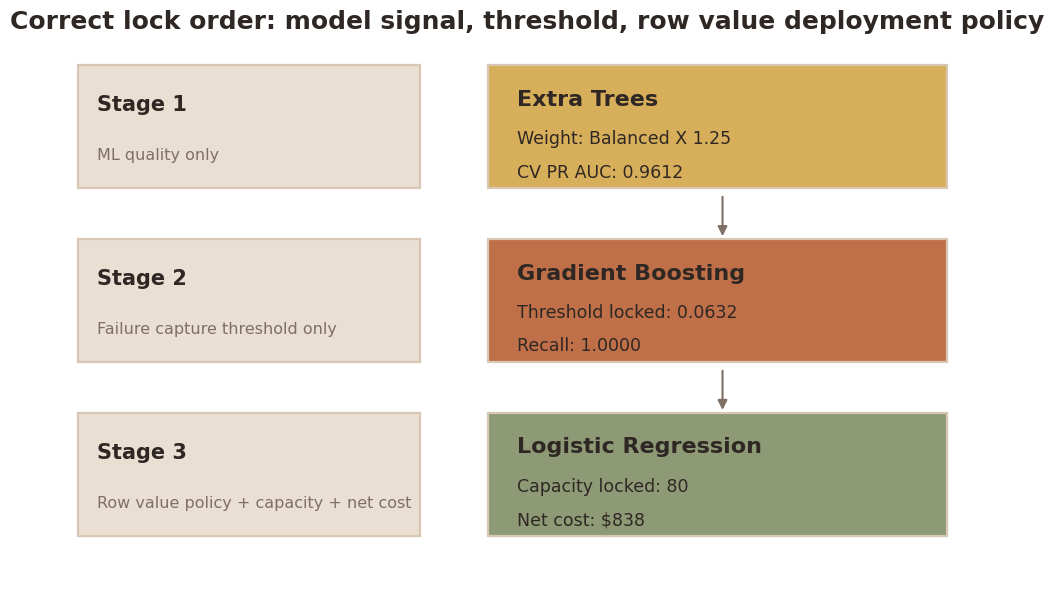

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Figure 1. Stage 1 locks only ML winner. Stage 2 locks only threshold. Stage 3 locks row value policy and net cost.</em></div>

## Candidate overview

This table shows every candidate from candidate_results.csv. The candidate table is not the final decision table; it is the raw saved evaluation used by the staged outputs.

,Rank,Model,Weight,Fit,CV PR AUC,Validation PR AUC,Validation ROC AUC,Brier,ECE,Own best threshold,False negatives,Recall,Own best capacity,Own net cost
0,1,Logistic Regression,None,fit_ok,0.9490,0.9672,0.9720,0.0680,0.0689,0.0362,0,1.0000,97,$970
1,2,Logistic Regression,Balanced X 0.75,fit_ok,0.9490,0.9672,0.9720,0.0681,0.0689,0.0360,0,1.0000,97,$970
2,3,Logistic Regression,Balanced,fit_ok,0.9481,0.9670,0.9720,0.0686,0.0692,0.0348,0,1.0000,96,$960
3,4,Logistic Regression,Balanced X 1.25,fit_ok,0.9477,0.9665,0.9716,0.0690,0.0655,0.0339,0,1.0000,96,$960
4,5,Logistic Regression,Balanced X 1.5,fit_ok,0.9474,0.9660,0.9712,0.0693,0.0657,0.0331,0,1.0000,96,$960
5,6,Extra Trees,Balanced X 0.75,fit_ok,0.9604,0.9626,0.9690,0.0741,0.0691,0.0322,0,1.0000,104,"$1,040"
6,7,Extra Trees,None,fit_ok,0.9607,0.9620,0.9683,0.0741,0.0670,0.0330,0,1.0000,104,"$1,040"
7,8,Extra Trees,Balanced X 1.25,fit_ok,0.9612,0.9614,0.9677,0.0733,0.0666,0.0292,0,1.0000,105,"$1,050"
8,9,Extra Trees,Balanced,fit_ok,0.9609,0.9611,0.9679,0.0739,0.0701,0.0313,0,1.0000,103,"$1,030"
9,10,Extra Trees,Balanced X 1.5,fit_ok,0.9603,0.9605,0.9667,0.0733,0.0710,0.0285,0,1.0000,106,"$1,060"


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 5. All candidates with ML, threshold, and candidate-level capacity metrics.</em></div>

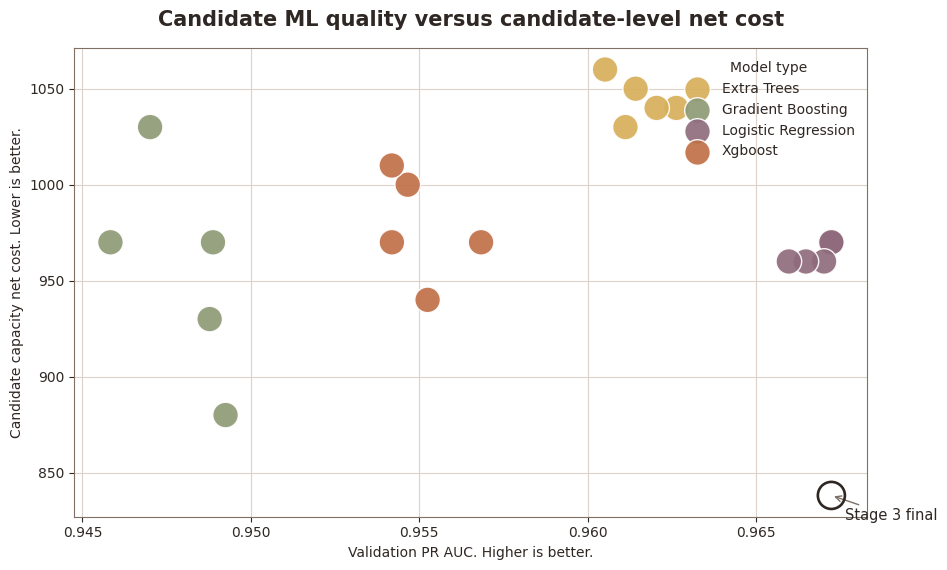

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Figure 2. Each point is a candidate. Bigger points have higher recall. Circled point is the Stage 3 final winner.</em></div>

## Final selected policy

This is the locked deployment rule from Stage 3. Rows above the locked threshold enter the urgent screen. Only urgent rows with positive expected net value remain actionable. The final queue is sorted by expected net value and inspected until locked capacity is reached.

,Metric,Value
0,Final model,Logistic Regression
1,Final weight,None
2,Locked threshold,0.0632
3,Locked daily capacity,80
4,Validation net cost,$838
5,Validation net cost vs inspect none,"$-50,303"
6,Row check cost,$10
7,Base row missed loss,$500
8,Row value recovery rate,1.0000
9,Row value features,"VOC,AQ,USS,footfall,Temperature"


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 6. Final Stage 3 selected policy loaded from locked_test_summary.csv.</em></div>

...

The test set is used only after Stage 3 locks the final model, threshold, row value rule, capacity, and net cost policy.

,Metric,Value
0,Test ROC AUC,0.9724
1,Test PR AUC,0.9431
2,Test Brier,0.0584
3,Test ECE,0.0544
4,Test max calibration gap,0.2733
5,Test positive value urgent pool,96
6,Test inspected today,80
7,Test saved failure value,"$57,135"
8,Test inspection cost,$800
9,Test missed loss,$36


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 7. Locked test results after all choices were fixed.</em></div>

,Action,Rows,Share
0,inspect_now,80,56.34%
1,monitor,43,30.28%
2,backlog_positive_value,16,11.27%
3,urgent_negative_value,3,2.11%


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 8. Test rows by final action under the locked row value rule.</em></div>

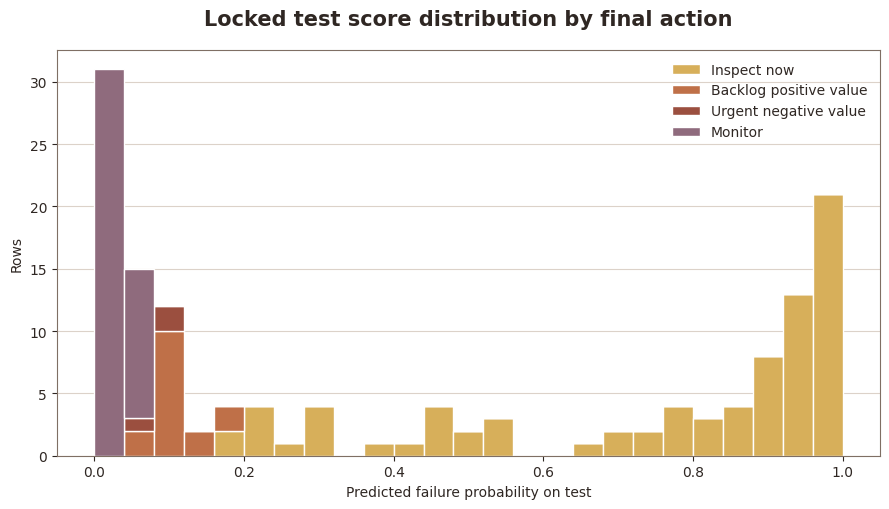

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Figure 3. Final actions from the saved locked test queue.</em></div>

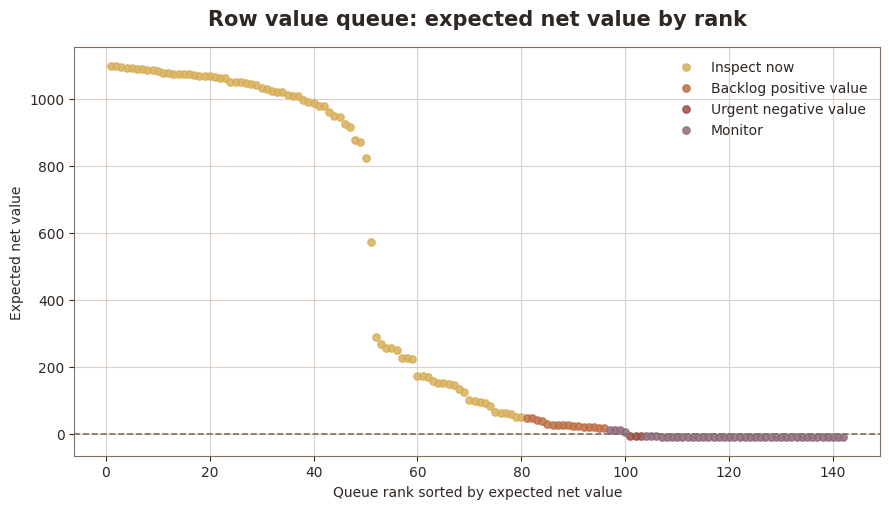

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Figure 4. Rows above zero expected net value are economically actionable under the locked assumptions.</em></div>

## Confusion matrix

This checks the locked threshold before capacity and row value limits are applied. It shows how many failed and non failed rows land in urgent versus monitor.

,threshold,actual_class,predicted_class,rows
0,0.063241,no_fail,monitor,43
1,0.063241,no_fail,urgent,40
2,0.063241,fail,monitor,0
3,0.063241,fail,urgent,59


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 9. Confusion matrix at the locked Stage 2 threshold.</em></div>

## Feature importance

These are the strongest signals for the final Stage 3 winning model. They are model importance scores, not causal effects.

,feature,importance,signed_coefficient,importance_type,importance_share
0,VOC,2.191557,2.191557,absolute_logistic_coefficient,0.423053
1,USS,1.223930,-1.223930,absolute_logistic_coefficient,0.236264
2,AQ,0.750555,0.750555,absolute_logistic_coefficient,0.144885
3,CS,0.555985,-0.555985,absolute_logistic_coefficient,0.107326
4,footfall,0.169425,-0.169425,absolute_logistic_coefficient,0.032705
5,Temperature,0.140737,0.140737,absolute_logistic_coefficient,0.027168
6,IP,0.061376,0.061376,absolute_logistic_coefficient,0.011848
7,RP,0.052303,0.052303,absolute_logistic_coefficient,0.010096
8,tempMode,0.034474,0.034474,absolute_logistic_coefficient,0.006655


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 10. Top feature importance rows saved by the pipeline.</em></div>

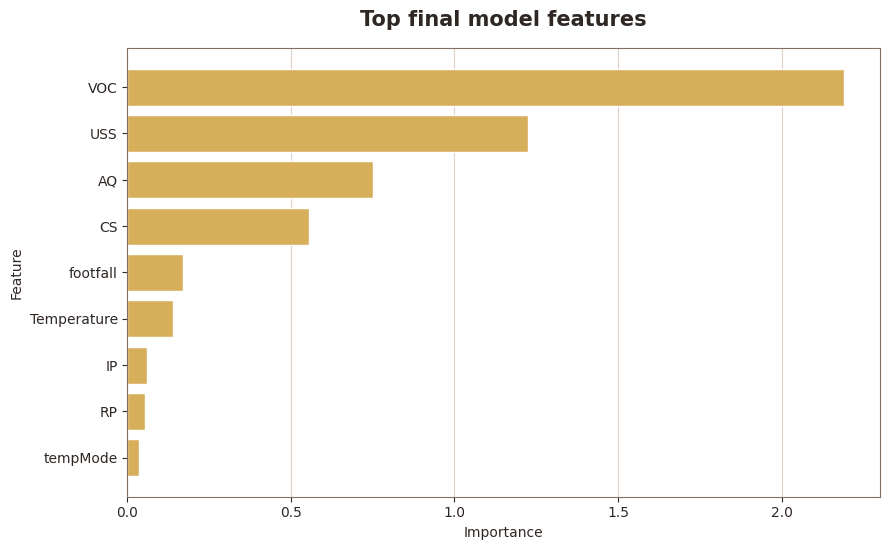

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Figure 5. Highest bars are the strongest model signals for the final locked winner.</em></div>

## Threshold stability

This keeps the final row value and capacity logic fixed, then checks nearby threshold multipliers. The selected threshold is multiplier 1.0.

,threshold_multiplier,threshold,selected_count,threshold_cost,threshold_net_value,threshold_precision,threshold_recall,false_positives,false_negatives,locked_capacity,capacity_inspected_today,capacity_urgent_pool,capacity_saved_failure_value,capacity_net_cost,capacity_net_value,capacity_missed_failure_cost,capacity_today_precision,capacity_total_failure_recall
0,0.85,0.0538,88,$918,"$50,184",0.6591,0.9831,30,1,80,80,84,"$51,103",$838,"$50,264",$38,0.7250,0.9831
1,0.90,0.0569,87,$908,"$50,194",0.6667,0.9831,29,1,80,80,83,"$51,103",$838,"$50,264",$38,0.7250,0.9831
2,0.95,0.0601,86,$898,"$50,204",0.6744,0.9831,28,1,80,80,83,"$51,103",$838,"$50,264",$38,0.7250,0.9831
3,1.00,0.0632,82,$858,"$50,244",0.7073,0.9831,24,1,80,80,81,"$51,103",$838,"$50,264",$38,0.7250,0.9831
4,1.05,0.0664,82,$858,"$50,244",0.7073,0.9831,24,1,80,80,81,"$51,103",$838,"$50,264",$38,0.7250,0.9831
5,1.10,0.0696,81,$848,"$50,254",0.7160,0.9831,23,1,80,80,81,"$51,103",$838,"$50,264",$38,0.7250,0.9831
6,1.15,0.0727,80,$838,"$50,264",0.7250,0.9831,22,1,80,80,80,"$51,103",$838,"$50,264",$38,0.7250,0.9831


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 11. Threshold stability check saved by the pipeline.</em></div>

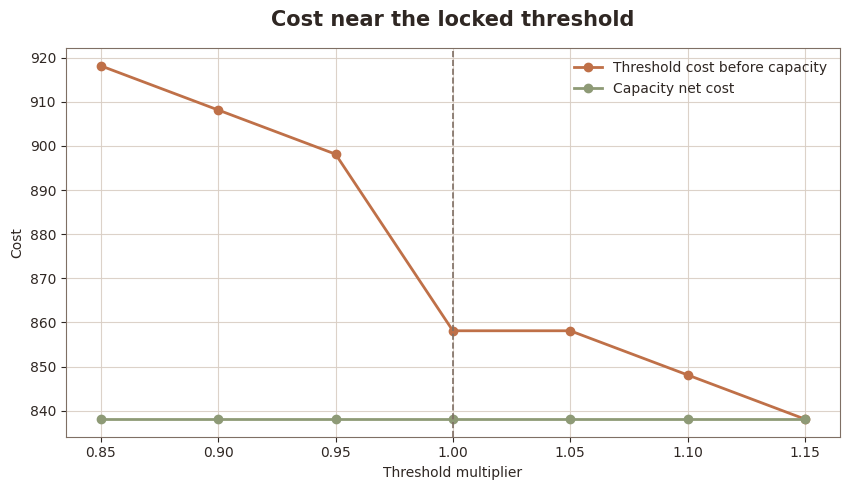

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Figure 6. The dashed line is the selected threshold multiplier of 1.0.</em></div>

## Cost and recovery sensitivity

This diagnostic keeps the final model, locked threshold, locked capacity, and row value ranking fixed. It then changes inspection cost, missed failure loss, and recovery rate.

,inspect_cost_multiplier,missed_cost_multiplier,recovery_rate,scenario_mean_inspect_cost,scenario_mean_missed_failure_cost,threshold,selected_count,threshold_cost,threshold_net_value,threshold_precision,threshold_recall,false_positives,false_negatives,locked_capacity,capacity_inspected_today,capacity_urgent_pool,capacity_saved_failure_value,capacity_net_cost,capacity_net_value,capacity_missed_failure_cost,capacity_today_precision,capacity_total_failure_recall
0,0.50,0.50,0.60,$5,$266,0.063241,99,$495,"$16,656",0.5960,1.0000,40,0,80,80,96,"$17,140",$418,"$16,722",$18,0.7250,0.9831
1,1.00,0.50,0.60,$10,$266,0.063241,99,$990,"$16,161",0.5960,1.0000,40,0,80,80,91,"$17,140",$818,"$16,322",$18,0.7250,0.9831
2,1.50,0.50,0.60,$15,$266,0.063241,99,"$1,485","$15,666",0.5960,1.0000,40,0,80,80,83,"$17,140","$1,218","$15,922",$18,0.7250,0.9831
3,0.50,1.00,0.60,$5,$532,0.063241,99,$495,"$33,807",0.5960,1.0000,40,0,80,80,96,"$34,281",$436,"$33,845",$36,0.7250,0.9831
4,1.00,1.00,0.60,$10,$532,0.063241,99,$990,"$33,312",0.5960,1.0000,40,0,80,80,96,"$34,281",$836,"$33,445",$36,0.7250,0.9831
5,1.50,1.00,0.60,$15,$532,0.063241,99,"$1,485","$32,817",0.5960,1.0000,40,0,80,80,96,"$34,281","$1,236","$33,045",$36,0.7250,0.9831
6,0.50,1.50,0.60,$5,$797,0.063241,99,$495,"$50,959",0.5960,1.0000,40,0,80,80,96,"$51,421",$454,"$50,967",$54,0.7250,0.9831
7,1.00,1.50,0.60,$10,$797,0.063241,99,$990,"$50,464",0.5960,1.0000,40,0,80,80,96,"$51,421",$854,"$50,567",$54,0.7250,0.9831
8,1.50,1.50,0.60,$15,$797,0.063241,99,"$1,485","$49,969",0.5960,1.0000,40,0,80,80,96,"$51,421","$1,254","$50,167",$54,0.7250,0.9831
9,0.50,0.50,0.80,$5,$266,0.063241,99,$495,"$22,373",0.5960,1.0000,40,0,80,80,96,"$22,854",$418,"$22,436",$18,0.7250,0.9831


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 12. Cost and recovery sensitivity saved by the pipeline.</em></div>

...

Sensitivity range. Across the tested assumptions, capacity net cost ranges from $418 to $1,254.

## Baseline comparison

The locked row value policy is compared against simple alternatives. Lower net cost is better.

,baseline,description,inspected_today,urgent_pool,net_cost,net_value,today_precision,recall,threshold_cost_before_capacity
0,locked_model_threshold_value_capacity,"Use selected model, locked threshold, row value ranking, and locked capacity.",80,96,$836,"$56,299",0.7250,0.9831,$990
1,inspect_none,Inspect no rows and miss every failure.,0,0,"$57,171","$-57,171",0.0000,0.0000,"$57,171"
2,inspect_all,Inspect every test row.,142,142,"$1,420","$55,751",0.4155,1.0000,"$1,420"
3,random_capacity_mean,Randomly inspect locked daily capacity.,80,80,"$25,720","$-25,720",0.4177,0.5663,$nan


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 14. Baseline comparison saved by the pipeline.</em></div>

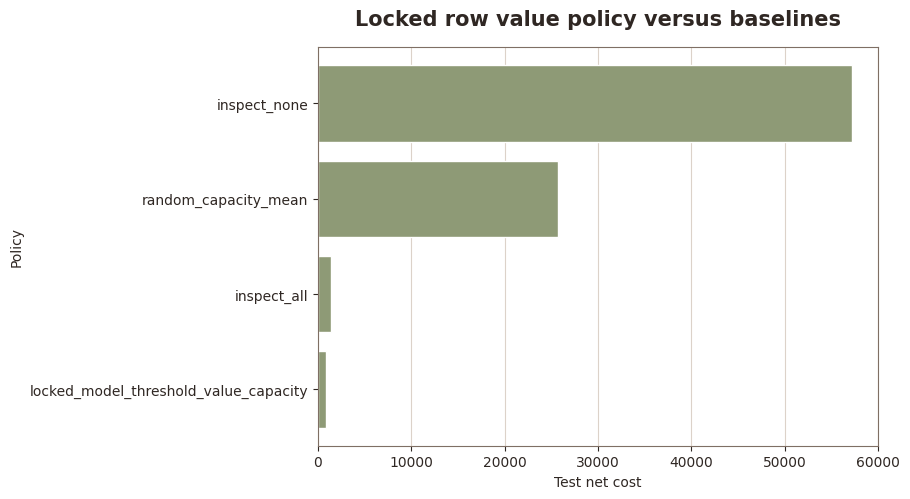

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Figure 7. Lower net cost is better.</em></div>

## Leakage check

This confirms the intended split discipline and staged locking order. The row value severity rule is learned from train only. Validation selects the Stage 3 policy. Test is held for final reporting only.

,check,status,detail
0,split_is_train_validation_test,pass,"Rows split into train=659, validation=142, tes..."
1,stage_1_no_cost_no_threshold_lock,pass,Stage 1 locks only the ML-quality winner.
2,stage_2_threshold_only,pass,Stage 2 locks only the failure-capture threshold.
3,stage_3_final_policy_lock,pass,"Stage 3 locks final model, locked threshold, r..."
4,row_value_rules_train_only,pass,Row value severity rules are learned from trai...
5,test_used_once_after_lock,pass,Test is scored after final policy is selected.
6,preprocessing_inside_pipeline,pass,Preprocessing stays inside train-fitted pipeli...


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 15. Leakage checks saved by the pipeline.</em></div>

## Final interpretation

Final locked policy: Logistic Regression with None, threshold 0.0632, capacity 80, and validation net cost $838.

On test, the policy inspects 80 rows today from a positive value urgent pool of 96. Test net cost is $836, today precision is 0.7250, and capacity recall is 0.9831.

Bottom line. Stage 1 proves ML signal quality. Stage 2 locks the failure capture threshold. Stage 3 applies that locked threshold, keeps only positive expected value rows, ranks them by expected net value, adds realistic capacity, and selects the final model by net cost while keeping ML reliability visible.

In [2]:
# =========================
# CELL 2 v4 - stage 3 add gain loss
# =========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = str


# -------------------------
# Saved outputs from Cell 1 v3 row value update
# -------------------------
CANDIDATE_PATH = Path("/kaggle/working/candidate_results.csv")
STAGE1_PATH = Path("/kaggle/working/stage1_ml_quality_results.csv")
STAGE2_PATH = Path("/kaggle/working/stage2_threshold_capture_results.csv")
STAGE3_PATH = Path("/kaggle/working/stage3_final_policy_results.csv")

SUMMARY_PATH = Path("/kaggle/working/locked_test_summary.csv")
QUEUE_PATH = Path("/kaggle/working/locked_test_queue.csv")
CONFUSION_PATH = Path("/kaggle/working/locked_test_confusion_matrix.csv")
FEATURE_IMPORTANCE_PATH = Path("/kaggle/working/winning_model_feature_importance.csv")
THRESHOLD_STABILITY_PATH = Path("/kaggle/working/threshold_stability_check.csv")
BASELINE_PATH = Path("/kaggle/working/baseline_comparison.csv")
COST_SENSITIVITY_PATH = Path("/kaggle/working/cost_recovery_sensitivity.csv")
LEAKAGE_CHECK_PATH = Path("/kaggle/working/leakage_check.csv")


candidate_df = pd.read_csv(CANDIDATE_PATH)
stage1_df = pd.read_csv(STAGE1_PATH)
stage2_df = pd.read_csv(STAGE2_PATH)
stage3_df = pd.read_csv(STAGE3_PATH)

summary_df = pd.read_csv(SUMMARY_PATH)
queue_df = pd.read_csv(QUEUE_PATH)
confusion_df = pd.read_csv(CONFUSION_PATH)
feature_importance_df = pd.read_csv(FEATURE_IMPORTANCE_PATH)
threshold_stability_df = pd.read_csv(THRESHOLD_STABILITY_PATH)
baseline_df = pd.read_csv(BASELINE_PATH)
cost_sensitivity_df = pd.read_csv(COST_SENSITIVITY_PATH)
leakage_check_df = pd.read_csv(LEAKAGE_CHECK_PATH)

summary_row = summary_df.iloc[0]


# -------------------------
# Style helpers
# -------------------------
PALETTE = {
    "sand": "#E9DFD2",
    "sand_dark": "#D7C7B3",
    "gold": "#D7AF5A",
    "rust": "#BF7048",
    "olive": "#8E9A76",
    "plum": "#8F6B7D",
    "ink": "#2F2723",
    "muted": "#7F6F64",
    "grid": "#D9CEC4",
    "inspect": "#D7AF5A",
    "backlog": "#BF7048",
    "urgent_bad": "#9B4F3F",
    "monitor": "#8F6B7D",
}

plt.rcParams["axes.edgecolor"] = PALETTE["muted"]
plt.rcParams["axes.labelcolor"] = PALETTE["ink"]
plt.rcParams["xtick.color"] = PALETTE["ink"]
plt.rcParams["ytick.color"] = PALETTE["ink"]
plt.rcParams["text.color"] = PALETTE["ink"]


def show_md(text):
    display(Markdown(text))


def show_caption(text):
    show_md(
        f"<div style='margin-top:6px; color:{PALETTE['muted']}; font-size:0.95em;'><em>{text}</em></div>"
    )


def fmt_model(name):
    return str(name).replace("_", " ").title()


def fmt_weight(name):
    name = str(name)
    if name == "none":
        return "None"
    return name.replace("_x", " x ").replace("_", " ").title()


def fmt_money(value):
    return f"${float(value):,.0f}"


def fmt_count(value):
    return f"{int(float(value)):,}"


def fmt_score(value):
    return f"{float(value):.4f}"


def get_value(row, names, default=np.nan):
    for name in names:
        if name in row.index and pd.notna(row[name]):
            return row[name]
    return default


def existing_cols(df, cols):
    return [c for c in cols if c in df.columns]


def format_existing(styler, fmt_map):
    return styler.format({k: v for k, v in fmt_map.items() if k in styler.data.columns})


def display_ranked_table(df, cols, rename_map, fmt_map, caption):
    out = df[existing_cols(df, cols)].copy()
    out = out.rename(columns={k: v for k, v in rename_map.items() if k in out.columns})
    styler = out.style
    styler = format_existing(styler, fmt_map)
    display(styler)
    show_caption(caption)


usable = candidate_df[candidate_df["fit_error"].fillna("").eq("")].copy().reset_index(drop=True)

inspect_cost_value = get_value(summary_row, ["inspect_cost", "row_check_cost"])
base_missed_value = get_value(summary_row, ["base_missed_failure_cost", "missed_failure_cost"])
recovery_value = get_value(summary_row, ["row_value_recovery_rate"], 1.0)


# -------------------------
# Report intro
# -------------------------
show_md("# Machine Risk Triage: Staged ML to Row Value Operations Policy")
show_md(
    "This report reads the CSV outputs saved by the updated Cell 1 v3. "
    "Nothing is reselected here. The report shows the staged locks: "
    "Stage 1 locks only the ML model winner, Stage 2 locks only the threshold, "
    "and Stage 3 locks the final model, threshold, row value queue, capacity, and net cost."
)

show_md("## Setup")
setup_rows = [
    ["Rows", "Independent machine observations"],
    ["Target", "fail"],
    ["Train / validation / test split", "About 70 / 15 / 15"],
    ["Row check cost", fmt_money(inspect_cost_value)],
    ["Base row missed loss", fmt_money(base_missed_value)],
    ["Row value recovery rate", fmt_score(recovery_value)],
    ["Cost source", "Scania APS proxy: 10 for unnecessary check, 500 for missed faulty machine"],
    ["Row value rule", "Severity multipliers learned from train only, then applied to validation and test"],
    ["Candidate grid", f"{len(usable)} model-weight candidate setups"],
    ["Report rule", "Read saved Cell 1 v3 outputs only"],
]

if "row_value_features_used" in summary_row.index:
    setup_rows.append(["Row value features", str(summary_row["row_value_features_used"])])
if "row_value_train_base_failure_rate" in summary_row.index:
    setup_rows.append(["Train base failure rate", fmt_score(summary_row["row_value_train_base_failure_rate"])])

setup_table = pd.DataFrame(setup_rows, columns=["Item", "Choice used in notebook"])
display(setup_table)
show_caption("Table 1. Split, Scania proxy values, row value rule, and reporting rule.")


# -------------------------
# Stage 1
# -------------------------
show_md("## Stage 1: ML model winner only")
show_md(
    "Stage 1 uses ML quality only. It does not use cost, capacity, threshold locking, or row value ranking. "
    "This stage answers which model learns the failure signal best."
)

stage1_top = stage1_df.head(10).copy()
stage1_top["model_label"] = stage1_top["model_name"].apply(fmt_model)
stage1_top["weight_label"] = stage1_top["weight_style"].apply(fmt_weight)

display_ranked_table(
    stage1_top,
    [
        "model_label",
        "weight_label",
        "cv_pr_auc_mean",
        "cv_pr_auc_std",
        "cv_roc_auc_mean",
        "validation_pr_auc",
        "validation_roc_auc",
        "validation_brier",
        "validation_ece",
        "overfit_pr_auc_gap",
        "excluded_from_stage",
    ],
    {
        "model_label": "Model",
        "weight_label": "Weight",
        "cv_pr_auc_mean": "CV PR AUC mean",
        "cv_pr_auc_std": "CV PR AUC std",
        "cv_roc_auc_mean": "CV ROC AUC mean",
        "validation_pr_auc": "Validation PR AUC",
        "validation_roc_auc": "Validation ROC AUC",
        "validation_brier": "Validation Brier",
        "validation_ece": "Validation ECE",
        "overfit_pr_auc_gap": "Overfit PR AUC gap",
        "excluded_from_stage": "Not used here",
    },
    {
        "CV PR AUC mean": "{:.4f}",
        "CV PR AUC std": "{:.4f}",
        "CV ROC AUC mean": "{:.4f}",
        "Validation PR AUC": "{:.4f}",
        "Validation ROC AUC": "{:.4f}",
        "Validation Brier": "{:.4f}",
        "Validation ECE": "{:.4f}",
        "Overfit PR AUC gap": "{:.4f}",
    },
    "Table 2. Stage 1 ranking. Cost, capacity, threshold locking, and row value ranking are intentionally excluded.",
)

stage1_winner = stage1_df.iloc[0]
show_md(
    f"Stage 1 winner: {fmt_model(stage1_winner['model_name'])} with {fmt_weight(stage1_winner['weight_style'])}. "
    f"CV PR AUC mean is {float(stage1_winner['cv_pr_auc_mean']):.4f}."
)


# -------------------------
# Stage 2
# -------------------------
show_md("## Stage 2: Threshold winner for failure capture")
show_md(
    "Stage 2 keeps comparing all valid models. For each model, it finds the threshold that catches real failures best. "
    "This stage locks only the threshold. It does not lock the final model, capacity, final net cost, or row value queue."
)

stage2_top = stage2_df.head(10).copy()
stage2_top["model_label"] = stage2_top["model_name"].apply(fmt_model)
stage2_top["weight_label"] = stage2_top["weight_style"].apply(fmt_weight)

display_ranked_table(
    stage2_top,
    [
        "model_label",
        "weight_label",
        "validation_best_threshold",
        "validation_false_negatives",
        "validation_recall",
        "validation_precision",
        "validation_selected_count",
        "validation_true_positives",
        "validation_false_positives",
        "validation_pr_auc",
        "validation_brier",
        "validation_ece",
        "excluded_from_stage",
    ],
    {
        "model_label": "Model",
        "weight_label": "Weight",
        "validation_best_threshold": "Best threshold",
        "validation_false_negatives": "False negatives",
        "validation_recall": "Recall",
        "validation_precision": "Precision",
        "validation_selected_count": "Urgent rows",
        "validation_true_positives": "True positives",
        "validation_false_positives": "False positives",
        "validation_pr_auc": "PR AUC",
        "validation_brier": "Brier",
        "validation_ece": "ECE",
        "excluded_from_stage": "Not used here",
    },
    {
        "Best threshold": "{:.4f}",
        "False negatives": "{:,.0f}",
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "Urgent rows": "{:,.0f}",
        "True positives": "{:,.0f}",
        "False positives": "{:,.0f}",
        "PR AUC": "{:.4f}",
        "Brier": "{:.4f}",
        "ECE": "{:.4f}",
    },
    "Table 3. Stage 2 ranking. The winner locks the threshold only.",
)

stage2_winner = stage2_df.iloc[0]
locked_threshold = float(stage2_winner["validation_best_threshold"])
show_md(
    f"Stage 2 threshold winner: {fmt_model(stage2_winner['model_name'])} with {fmt_weight(stage2_winner['weight_style'])}. "
    f"The locked threshold is {locked_threshold:.4f}. "
    f"This locks the threshold only, not the final model."
)


# -------------------------
# Stage 3
# -------------------------
show_md("## Stage 3: Final deployment winner with row value gain/loss")
show_md(
    "Stage 3 uses the locked threshold from Stage 2. It then compares every model at that same threshold. "
    "Rows enter the action queue only when they are urgent and have positive expected net value. "
    "The queue is sorted by expected net value, then probability. This is the only stage that locks final model, row value queue, capacity, and net cost."
)

stage3_top = stage3_df.head(10).copy()
stage3_top["model_label"] = stage3_top["model_name"].apply(fmt_model)
stage3_top["weight_label"] = stage3_top["weight_style"].apply(fmt_weight)

display_ranked_table(
    stage3_top,
    [
        "model_label",
        "weight_label",
        "locked_threshold_from_stage_2",
        "locked_capacity",
        "urgent_pool",
        "expected_net_value_sum",
        "saved_failure_value",
        "net_cost",
        "net_value",
        "net_cost_vs_inspect_none",
        "base_inspect_cost",
        "missed_failure_cost_total",
        "locked_threshold_false_negatives",
        "locked_threshold_recall",
        "today_precision",
        "total_failure_recall_after_capacity",
        "validation_pr_auc",
        "validation_roc_auc",
        "validation_brier",
        "validation_ece",
        "excluded_from_stage",
    ],
    {
        "model_label": "Model",
        "weight_label": "Weight",
        "locked_threshold_from_stage_2": "Locked threshold",
        "locked_capacity": "Locked capacity",
        "urgent_pool": "Positive value urgent pool",
        "expected_net_value_sum": "Expected net value sum",
        "saved_failure_value": "Saved failure value",
        "net_cost": "Net cost",
        "net_value": "Net value",
        "net_cost_vs_inspect_none": "Net cost vs inspect none",
        "base_inspect_cost": "Inspect cost",
        "missed_failure_cost_total": "Missed loss",
        "locked_threshold_false_negatives": "Threshold false negatives",
        "locked_threshold_recall": "Threshold recall",
        "today_precision": "Today precision",
        "total_failure_recall_after_capacity": "Capacity recall",
        "validation_pr_auc": "PR AUC",
        "validation_roc_auc": "ROC AUC",
        "validation_brier": "Brier",
        "validation_ece": "ECE",
        "excluded_from_stage": "Not used here",
    },
    {
        "Locked threshold": "{:.4f}",
        "Locked capacity": "{:,.0f}",
        "Positive value urgent pool": "{:,.0f}",
        "Expected net value sum": "${:,.0f}",
        "Saved failure value": "${:,.0f}",
        "Net cost": "${:,.0f}",
        "Net value": "${:,.0f}",
        "Net cost vs inspect none": "${:,.0f}",
        "Inspect cost": "${:,.0f}",
        "Missed loss": "${:,.0f}",
        "Threshold false negatives": "{:,.0f}",
        "Threshold recall": "{:.4f}",
        "Today precision": "{:.4f}",
        "Capacity recall": "{:.4f}",
        "PR AUC": "{:.4f}",
        "ROC AUC": "{:.4f}",
        "Brier": "{:.4f}",
        "ECE": "{:.4f}",
    },
    "Table 4. Stage 3 ranking. Threshold search is excluded because the threshold was already locked in Stage 2.",
)

stage3_winner = stage3_df.iloc[0]
show_md(
    f"Stage 3 final winner: {fmt_model(stage3_winner['model_name'])} with {fmt_weight(stage3_winner['weight_style'])}. "
    f"Locked threshold is {float(stage3_winner['locked_threshold_from_stage_2']):.4f}, "
    f"locked capacity is {int(stage3_winner['locked_capacity']):,}, "
    f"and validation net cost is {fmt_money(stage3_winner['net_cost'])}."
)


# -------------------------
# Staged decision path figure
# -------------------------
show_md("## Staged decision path")

fig, ax = plt.subplots(figsize=(11.5, 6.0))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

left_x = 0.04
right_x = 0.46
left_w = 0.35
right_w = 0.47
box_h = 0.22
ys = [0.70, 0.39, 0.08]

left_texts = [
    ("Stage 1", "ML quality only"),
    ("Stage 2", "Failure capture threshold only"),
    ("Stage 3", "Row value policy + capacity + net cost"),
]

right_texts = [
    (
        f"{fmt_model(summary_row['stage_1_ml_winner_model'])}\n"
        f"Weight: {fmt_weight(summary_row['stage_1_ml_winner_weight'])}\n"
        f"CV PR AUC: {float(summary_row['stage_1_cv_pr_auc_mean']):.4f}"
    ),
    (
        f"{fmt_model(summary_row['stage_2_threshold_winner_model'])}\n"
        f"Threshold locked: {float(summary_row['stage_2_locked_threshold']):.4f}\n"
        f"Recall: {float(summary_row['stage_2_validation_recall']):.4f}"
    ),
    (
        f"{fmt_model(summary_row['stage_3_final_model'])}\n"
        f"Capacity locked: {int(summary_row['stage_3_locked_capacity']):,}\n"
        f"Net cost: {fmt_money(summary_row['stage_3_validation_net_cost'])}"
    ),
]

right_colors = [PALETTE["gold"], PALETTE["rust"], PALETTE["olive"]]

for i, y in enumerate(ys):
    ax.add_patch(Rectangle((left_x, y), left_w, box_h, facecolor=PALETTE["sand"], edgecolor=PALETTE["sand_dark"], linewidth=1.6))
    ax.add_patch(Rectangle((right_x, y), right_w, box_h, facecolor=right_colors[i], edgecolor=PALETTE["sand_dark"], linewidth=1.6))

    ax.text(left_x + 0.02, y + 0.15, left_texts[i][0], ha="left", va="center", fontsize=15, fontweight="semibold", color=PALETTE["ink"])
    ax.text(left_x + 0.02, y + 0.06, left_texts[i][1], ha="left", va="center", fontsize=11.5, color=PALETTE["muted"])

    lines = right_texts[i].split("\n")
    ax.text(right_x + 0.03, y + 0.16, lines[0], ha="left", va="center", fontsize=16, fontweight="semibold", color=PALETTE["ink"])
    ax.text(right_x + 0.03, y + 0.09, lines[1], ha="left", va="center", fontsize=12.5, color=PALETTE["ink"])
    ax.text(right_x + 0.03, y + 0.03, lines[2], ha="left", va="center", fontsize=12.5, color=PALETTE["ink"])

for start_y, end_y in [(0.69, 0.61), (0.38, 0.30)]:
    ax.add_patch(FancyArrowPatch(
        (0.70, start_y), (0.70, end_y),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.5,
        color=PALETTE["muted"],
    ))

ax.text(
    0.5,
    1.02,
    "Correct lock order: model signal, threshold, row value deployment policy",
    ha="center",
    va="top",
    fontsize=18,
    fontweight="bold",
    color=PALETTE["ink"],
)

fig.subplots_adjust(top=0.88)
plt.tight_layout()
plt.show()
show_caption("Figure 1. Stage 1 locks only ML winner. Stage 2 locks only threshold. Stage 3 locks row value policy and net cost.")


# -------------------------
# Candidate overview
# -------------------------
show_md("## Candidate overview")
show_md(
    "This table shows every candidate from candidate_results.csv. "
    "The candidate table is not the final decision table; it is the raw saved evaluation used by the staged outputs."
)

candidate_show = candidate_df.copy()
candidate_show["fit_error"] = candidate_show["fit_error"].fillna("")
candidate_show["fit_status"] = np.where(candidate_show["fit_error"].eq(""), "fit_ok", "fit_error")
candidate_show["model_label"] = candidate_show["model_name"].apply(fmt_model)
candidate_show["weight_label"] = candidate_show["weight_style"].apply(fmt_weight)

sort_cols = existing_cols(candidate_show, ["validation_pr_auc", "validation_roc_auc", "validation_brier"])
if sort_cols:
    candidate_show = candidate_show.sort_values(
        sort_cols,
        ascending=[False, False, True][:len(sort_cols)],
    ).reset_index(drop=True)

candidate_show["rank"] = np.arange(1, len(candidate_show) + 1)

display_ranked_table(
    candidate_show,
    [
        "rank",
        "model_label",
        "weight_label",
        "fit_status",
        "cv_pr_auc_mean",
        "validation_pr_auc",
        "validation_roc_auc",
        "validation_brier",
        "validation_ece",
        "validation_best_threshold",
        "validation_false_negatives",
        "validation_recall",
        "best_capacity",
        "best_capacity_net_cost",
    ],
    {
        "rank": "Rank",
        "model_label": "Model",
        "weight_label": "Weight",
        "fit_status": "Fit",
        "cv_pr_auc_mean": "CV PR AUC",
        "validation_pr_auc": "Validation PR AUC",
        "validation_roc_auc": "Validation ROC AUC",
        "validation_brier": "Brier",
        "validation_ece": "ECE",
        "validation_best_threshold": "Own best threshold",
        "validation_false_negatives": "False negatives",
        "validation_recall": "Recall",
        "best_capacity": "Own best capacity",
        "best_capacity_net_cost": "Own net cost",
    },
    {
        "CV PR AUC": "{:.4f}",
        "Validation PR AUC": "{:.4f}",
        "Validation ROC AUC": "{:.4f}",
        "Brier": "{:.4f}",
        "ECE": "{:.4f}",
        "Own best threshold": "{:.4f}",
        "False negatives": "{:,.0f}",
        "Recall": "{:.4f}",
        "Own best capacity": "{:,.0f}",
        "Own net cost": "${:,.0f}",
    },
    "Table 5. All candidates with ML, threshold, and candidate-level capacity metrics.",
)


# -------------------------
# Candidate scatter chart
# -------------------------
fit_ok = candidate_show[candidate_show["fit_status"].eq("fit_ok")].copy()

if not fit_ok.empty and {"validation_pr_auc", "best_capacity_net_cost"}.issubset(fit_ok.columns):
    model_color_map = {
        "logistic_regression": PALETTE["plum"],
        "extra_trees": PALETTE["gold"],
        "gradient_boosting": PALETTE["olive"],
        "xgboost": PALETTE["rust"],
    }

    fig, ax = plt.subplots(figsize=(9.6, 5.8))

    for model_name, group in fit_ok.groupby("model_name"):
        point_size = 80
        if "validation_recall" in group.columns:
            point_size = 80 + group["validation_recall"].fillna(0).clip(0, 1) * 260

        ax.scatter(
            group["validation_pr_auc"],
            group["best_capacity_net_cost"],
            s=point_size,
            color=model_color_map.get(model_name, PALETTE["muted"]),
            edgecolor="white",
            linewidth=1.0,
            alpha=0.92,
            label=fmt_model(model_name),
        )

    final_row = stage3_df.iloc[0]
    ax.scatter(
        [final_row["validation_pr_auc"]],
        [final_row["net_cost"]],
        s=380,
        facecolor="none",
        edgecolor=PALETTE["ink"],
        linewidth=1.9,
        zorder=5,
    )
    ax.annotate(
        "Stage 3 final",
        xy=(final_row["validation_pr_auc"], final_row["net_cost"]),
        xytext=(10, -18),
        textcoords="offset points",
        fontsize=10.5,
        color=PALETTE["ink"],
        arrowprops=dict(arrowstyle="->", color=PALETTE["muted"], linewidth=1.0),
    )

    ax.set_xlabel("Validation PR AUC. Higher is better.")
    ax.set_ylabel("Candidate capacity net cost. Lower is better.")
    ax.set_title(
        "Candidate ML quality versus candidate-level net cost",
        pad=16,
        fontsize=15,
        fontweight="semibold",
        color=PALETTE["ink"],
    )
    ax.grid(color=PALETTE["grid"], linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, title="Model type")
    plt.tight_layout()
    plt.show()

    show_caption("Figure 2. Each point is a candidate. Bigger points have higher recall. Circled point is the Stage 3 final winner.")


# -------------------------
# Final selected policy
# -------------------------
show_md("## Final selected policy")
show_md(
    "This is the locked deployment rule from Stage 3. Rows above the locked threshold enter the urgent screen. "
    "Only urgent rows with positive expected net value remain actionable. The final queue is sorted by expected net value and inspected until locked capacity is reached."
)

policy_rows = [
    ["Final model", fmt_model(summary_row["stage_3_final_model"])],
    ["Final weight", fmt_weight(summary_row["stage_3_final_weight"])],
    ["Locked threshold", fmt_score(summary_row["stage_3_locked_threshold"])],
    ["Locked daily capacity", fmt_count(summary_row["stage_3_locked_capacity"])],
    ["Validation net cost", fmt_money(summary_row["stage_3_validation_net_cost"])],
    ["Validation net cost vs inspect none", fmt_money(summary_row["stage_3_validation_net_cost_vs_inspect_none"])],
    ["Row check cost", fmt_money(inspect_cost_value)],
    ["Base row missed loss", fmt_money(base_missed_value)],
    ["Row value recovery rate", fmt_score(recovery_value)],
]

if "row_value_features_used" in summary_row.index:
    policy_rows.append(["Row value features", str(summary_row["row_value_features_used"])])

policy_table = pd.DataFrame(policy_rows, columns=["Metric", "Value"])
display(policy_table)
show_caption("Table 6. Final Stage 3 selected policy loaded from locked_test_summary.csv.")


# -------------------------
# Locked test performance
# -------------------------
show_md("## Locked test performance")
show_md(
    "The test set is used only after Stage 3 locks the final model, threshold, row value rule, capacity, and net cost policy."
)

action_summary = queue_df["action"].value_counts(dropna=False).rename_axis("Action").reset_index(name="Rows")
action_summary["Share"] = action_summary["Rows"] / max(len(queue_df), 1)

test_rows = [
    ["Test ROC AUC", fmt_score(summary_row["test_roc_auc"])],
    ["Test PR AUC", fmt_score(summary_row["test_pr_auc"])],
    ["Test Brier", fmt_score(summary_row["test_brier"])],
    ["Test ECE", fmt_score(summary_row["test_ece"])],
    ["Test max calibration gap", fmt_score(summary_row["test_max_calibration_gap"])],
    ["Test positive value urgent pool", fmt_count(summary_row["test_urgent_pool"])],
    ["Test inspected today", fmt_count(summary_row["test_inspected_today"])],
    ["Test saved failure value", fmt_money(get_value(summary_row, ["test_saved_failure_value"], 0.0))],
    ["Test inspection cost", fmt_money(summary_row["test_base_inspect_cost"])],
    ["Test missed loss", fmt_money(summary_row["test_missed_failure_cost"])],
    ["Test net cost", fmt_money(summary_row["test_net_cost"])],
    ["Test net value", fmt_money(get_value(summary_row, ["test_net_value"], np.nan))],
    ["Test net cost vs inspect none", fmt_money(summary_row["test_net_cost_vs_inspect_none"])],
    ["Test today precision", fmt_score(summary_row["test_today_precision"])],
    ["Test capacity recall", fmt_score(summary_row["test_total_failure_recall_after_capacity"])],
]

test_table = pd.DataFrame(test_rows, columns=["Metric", "Value"])
display(test_table)
show_caption("Table 7. Locked test results after all choices were fixed.")

display(action_summary.style.format({"Share": "{:.2%}"}))
show_caption("Table 8. Test rows by final action under the locked row value rule.")


fig, ax = plt.subplots(figsize=(9.0, 5.2))
bins = np.linspace(0.0, 1.0, 26)

action_order = ["inspect_now", "backlog_positive_value", "urgent_negative_value", "monitor"]
action_colors = {
    "inspect_now": PALETTE["inspect"],
    "backlog_positive_value": PALETTE["backlog"],
    "urgent_negative_value": PALETTE["urgent_bad"],
    "monitor": PALETTE["monitor"],
}
action_labels = {
    "inspect_now": "Inspect now",
    "backlog_positive_value": "Backlog positive value",
    "urgent_negative_value": "Urgent negative value",
    "monitor": "Monitor",
}

data_list = []
color_list = []
label_list = []

for action in action_order:
    values = queue_df.loc[queue_df["action"].eq(action), "predicted_failure_probability"].astype(float).values
    if len(values) > 0:
        data_list.append(values)
        color_list.append(action_colors[action])
        label_list.append(action_labels[action])

if data_list:
    ax.hist(data_list, bins=bins, stacked=True, color=color_list, label=label_list, edgecolor="white", linewidth=1.0)
    ax.set_xlabel("Predicted failure probability on test")
    ax.set_ylabel("Rows")
    ax.set_title("Locked test score distribution by final action", pad=18, fontsize=15, fontweight="semibold", color=PALETTE["ink"])
    ax.grid(axis="y", color=PALETTE["grid"], linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
    show_caption("Figure 3. Final actions from the saved locked test queue.")


if {"expected_net_value", "action"}.issubset(queue_df.columns):
    fig, ax = plt.subplots(figsize=(9.0, 5.2))
    plot_df = queue_df.copy()
    plot_df["plot_rank"] = np.arange(1, len(plot_df) + 1)
    for action in action_order:
        g = plot_df[plot_df["action"].eq(action)]
        if len(g) == 0:
            continue
        ax.scatter(
            g["plot_rank"],
            g["expected_net_value"],
            s=28,
            alpha=0.85,
            color=action_colors[action],
            label=action_labels[action],
        )
    ax.axhline(0.0, color=PALETTE["muted"], linewidth=1.2, linestyle="--")
    ax.set_xlabel("Queue rank sorted by expected net value")
    ax.set_ylabel("Expected net value")
    ax.set_title("Row value queue: expected net value by rank", pad=16, fontsize=15, fontweight="semibold")
    ax.grid(color=PALETTE["grid"], linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
    show_caption("Figure 4. Rows above zero expected net value are economically actionable under the locked assumptions.")


# -------------------------
# Confusion matrix
# -------------------------
show_md("## Confusion matrix")
show_md(
    "This checks the locked threshold before capacity and row value limits are applied. "
    "It shows how many failed and non failed rows land in urgent versus monitor."
)

display(confusion_df)
show_caption("Table 9. Confusion matrix at the locked Stage 2 threshold.")


# -------------------------
# Feature importance
# -------------------------
show_md("## Feature importance")
show_md(
    "These are the strongest signals for the final Stage 3 winning model. "
    "They are model importance scores, not causal effects."
)

feature_top = feature_importance_df.head(15).copy()
display(feature_top)
show_caption("Table 10. Top feature importance rows saved by the pipeline.")

feature_col = "feature" if "feature" in feature_top.columns else feature_top.columns[0]
importance_col = "importance" if "importance" in feature_top.columns else feature_top.columns[-1]
plot_features = feature_top.sort_values(importance_col, ascending=True)

fig, ax = plt.subplots(figsize=(9.0, 5.6))
ax.barh(plot_features[feature_col], plot_features[importance_col], color=PALETTE["gold"], edgecolor="white")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.set_title("Top final model features", pad=16, fontsize=15, fontweight="semibold")
ax.grid(axis="x", color=PALETTE["grid"], linewidth=0.8, alpha=0.9)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
show_caption("Figure 5. Highest bars are the strongest model signals for the final locked winner.")


# -------------------------
# Threshold stability
# -------------------------
show_md("## Threshold stability")
show_md(
    "This keeps the final row value and capacity logic fixed, then checks nearby threshold multipliers. "
    "The selected threshold is multiplier 1.0."
)

threshold_format = {
    "threshold_multiplier": "{:.2f}",
    "threshold": "{:.4f}",
    "threshold_cost": "${:,.0f}",
    "threshold_net_value": "${:,.0f}",
    "threshold_precision": "{:.4f}",
    "threshold_recall": "{:.4f}",
    "capacity_saved_failure_value": "${:,.0f}",
    "capacity_net_cost": "${:,.0f}",
    "capacity_net_value": "${:,.0f}",
    "capacity_missed_failure_cost": "${:,.0f}",
    "capacity_today_precision": "{:.4f}",
    "capacity_total_failure_recall": "{:.4f}",
}
display(threshold_stability_df.style.format({k: v for k, v in threshold_format.items() if k in threshold_stability_df.columns}))
show_caption("Table 11. Threshold stability check saved by the pipeline.")

if {"threshold_multiplier", "threshold_cost", "capacity_net_cost"}.issubset(threshold_stability_df.columns):
    fig, ax = plt.subplots(figsize=(8.6, 5.0))

    ax.plot(
        threshold_stability_df["threshold_multiplier"],
        threshold_stability_df["threshold_cost"],
        marker="o",
        linewidth=2.0,
        color=PALETTE["rust"],
        label="Threshold cost before capacity",
    )
    ax.plot(
        threshold_stability_df["threshold_multiplier"],
        threshold_stability_df["capacity_net_cost"],
        marker="o",
        linewidth=2.0,
        color=PALETTE["olive"],
        label="Capacity net cost",
    )
    ax.axvline(1.0, color=PALETTE["muted"], linewidth=1.2, linestyle="--")
    ax.set_xlabel("Threshold multiplier")
    ax.set_ylabel("Cost")
    ax.set_title("Cost near the locked threshold", pad=16, fontsize=15, fontweight="semibold")
    ax.grid(color=PALETTE["grid"], linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    show_caption("Figure 6. The dashed line is the selected threshold multiplier of 1.0.")


# -------------------------
# Cost and recovery sensitivity
# -------------------------
show_md("## Cost and recovery sensitivity")
show_md(
    "This diagnostic keeps the final model, locked threshold, locked capacity, and row value ranking fixed. "
    "It then changes inspection cost, missed failure loss, and recovery rate."
)

cost_format = {
    "inspect_cost_multiplier": "{:.2f}",
    "missed_cost_multiplier": "{:.2f}",
    "recovery_rate": "{:.2f}",
    "scenario_mean_inspect_cost": "${:,.0f}",
    "scenario_mean_missed_failure_cost": "${:,.0f}",
    "scenario_inspect_cost": "${:,.0f}",
    "scenario_effective_missed_failure_cost": "${:,.0f}",
    "threshold_cost": "${:,.0f}",
    "threshold_net_value": "${:,.0f}",
    "threshold_precision": "{:.4f}",
    "threshold_recall": "{:.4f}",
    "capacity_saved_failure_value": "${:,.0f}",
    "capacity_net_cost": "${:,.0f}",
    "capacity_net_value": "${:,.0f}",
    "capacity_missed_failure_cost": "${:,.0f}",
    "capacity_today_precision": "{:.4f}",
    "capacity_total_failure_recall": "{:.4f}",
}

display(cost_sensitivity_df.style.format({k: v for k, v in cost_format.items() if k in cost_sensitivity_df.columns}))
show_caption("Table 12. Cost and recovery sensitivity saved by the pipeline.")

if {"recovery_rate", "capacity_net_cost"}.issubset(cost_sensitivity_df.columns):
    agg_map = {
        "min_net_cost": ("capacity_net_cost", "min"),
        "median_net_cost": ("capacity_net_cost", "median"),
        "max_net_cost": ("capacity_net_cost", "max"),
    }
    if "capacity_today_precision" in cost_sensitivity_df.columns:
        agg_map["avg_today_precision"] = ("capacity_today_precision", "mean")
    if "capacity_total_failure_recall" in cost_sensitivity_df.columns:
        agg_map["avg_capacity_recall"] = ("capacity_total_failure_recall", "mean")
    if "capacity_net_value" in cost_sensitivity_df.columns:
        agg_map["median_net_value"] = ("capacity_net_value", "median")

    sensitivity_summary = cost_sensitivity_df.groupby("recovery_rate", as_index=False).agg(**agg_map)

    display(sensitivity_summary.style.format({
        "recovery_rate": "{:.0%}",
        "min_net_cost": "${:,.0f}",
        "median_net_cost": "${:,.0f}",
        "max_net_cost": "${:,.0f}",
        "median_net_value": "${:,.0f}",
        "avg_today_precision": "{:.4f}",
        "avg_capacity_recall": "{:.4f}",
    }))
    show_caption("Table 13. Compact sensitivity summary by recovery rate.")

    best_sensitivity = cost_sensitivity_df.loc[cost_sensitivity_df["capacity_net_cost"].idxmin()]
    worst_sensitivity = cost_sensitivity_df.loc[cost_sensitivity_df["capacity_net_cost"].idxmax()]

    show_md(
        f"Sensitivity range. Across the tested assumptions, capacity net cost ranges from "
        f"{fmt_money(best_sensitivity['capacity_net_cost'])} to {fmt_money(worst_sensitivity['capacity_net_cost'])}."
    )


# -------------------------
# Baseline comparison
# -------------------------
show_md("## Baseline comparison")
show_md(
    "The locked row value policy is compared against simple alternatives. Lower net cost is better."
)

baseline_format = {
    "inspected_today": "{:,.0f}",
    "urgent_pool": "{:,.0f}",
    "net_cost": "${:,.0f}",
    "net_value": "${:,.0f}",
    "today_precision": "{:.4f}",
    "recall": "{:.4f}",
    "threshold_cost_before_capacity": "${:,.0f}",
}

display(baseline_df.style.format({k: v for k, v in baseline_format.items() if k in baseline_df.columns}))
show_caption("Table 14. Baseline comparison saved by the pipeline.")

if {"baseline", "net_cost"}.issubset(baseline_df.columns):
    plot_baseline = baseline_df.sort_values("net_cost", ascending=True).copy()

    fig, ax = plt.subplots(figsize=(9.2, 5.1))
    ax.barh(plot_baseline["baseline"], plot_baseline["net_cost"], color=PALETTE["olive"], edgecolor="white")
    ax.set_xlabel("Test net cost")
    ax.set_ylabel("Policy")
    ax.set_title("Locked row value policy versus baselines", pad=16, fontsize=15, fontweight="semibold", color=PALETTE["ink"])
    ax.grid(axis="x", color=PALETTE["grid"], linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    show_caption("Figure 7. Lower net cost is better.")


# -------------------------
# Leakage check
# -------------------------
show_md("## Leakage check")
show_md(
    "This confirms the intended split discipline and staged locking order. "
    "The row value severity rule is learned from train only. Validation selects the Stage 3 policy. Test is held for final reporting only."
)

display(leakage_check_df)
show_caption("Table 15. Leakage checks saved by the pipeline.")


# -------------------------
# Final interpretation
# -------------------------
show_md("## Final interpretation")

show_md(
    f"Final locked policy: {fmt_model(summary_row['stage_3_final_model'])} with "
    f"{fmt_weight(summary_row['stage_3_final_weight'])}, threshold "
    f"{float(summary_row['stage_3_locked_threshold']):.4f}, capacity "
    f"{int(summary_row['stage_3_locked_capacity']):,}, and validation net cost "
    f"{fmt_money(summary_row['stage_3_validation_net_cost'])}."
)

show_md(
    f"On test, the policy inspects {int(summary_row['test_inspected_today']):,} rows today "
    f"from a positive value urgent pool of {int(summary_row['test_urgent_pool']):,}. "
    f"Test net cost is {fmt_money(summary_row['test_net_cost'])}, "
    f"today precision is {float(summary_row['test_today_precision']):.4f}, "
    f"and capacity recall is {float(summary_row['test_total_failure_recall_after_capacity']):.4f}."
)

show_md(
    "Bottom line. Stage 1 proves ML signal quality. Stage 2 locks the failure capture threshold. "
    "Stage 3 applies that locked threshold, keeps only positive expected value rows, ranks them by expected net value, "
    "adds realistic capacity, and selects the final model by net cost while keeping ML reliability visible."
)